<a href="https://colab.research.google.com/github/fox-n/ML_course_homeworks/blob/main/Copy_of_HW_%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D0%B8%D0%B7%D0%B0%D1%86%D1%96%D1%97.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.max_colwidth', None)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn import metrics
import plotly.express as px
from sklearn.ensemble import IsolationForest
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score

**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [2]:
raw_df = pd.read_csv('/content/marketing_campaign.csv', sep="\t", index_col = 0 )

In [3]:
df = raw_df.copy()

In [4]:
df.describe()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2240 entries, 5524 to 9405
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   object 
 2   Marital_Status       2240 non-null   object 
 3   Income               2216 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Dt_Customer          2240 non-null   object 
 7   Recency              2240 non-null   int64  
 8   MntWines             2240 non-null   int64  
 9   MntFruits            2240 non-null   int64  
 10  MntMeatProducts      2240 non-null   int64  
 11  MntFishProducts      2240 non-null   int64  
 12  MntSweetProducts     2240 non-null   int64  
 13  MntGoldProds         2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   int

In [6]:
print(f'Кількість категоріальних колонок: {len(df.select_dtypes(include = "object").columns)}')

Кількість категоріальних колонок: 3


In [7]:
print(f'Кількість числових колонок: {len(df.select_dtypes(include = "number").columns)}')

Кількість числових колонок: 25


In [8]:
print(df.isna().sum())

Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


#### Огляд даних
Дані містять 2240 rows × 28 columns -
3 категоріальні колонки та 25 числових.
Колонка Income маж 24 рядка з пропущеними значеннями - це близько 1% значень.

**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

<Axes: ylabel='Income'>

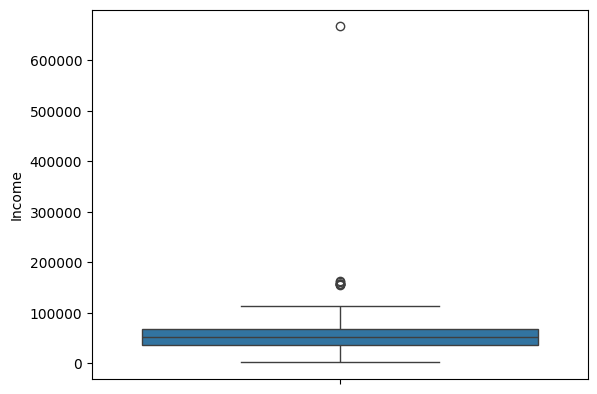

In [9]:
sns.boxplot(y=df["Income"])

In [10]:
df['Income'].median()

51381.5

In [11]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [12]:
df["Income"].isna().sum()

np.int64(0)

#### Заповнення пропущених значень
Я зробила заповнення пропущених значень медіаною, тому що Income має викид зі значенням близько 660к і заповнення середнім могло би повпливати на кластеризацію.

###Preprocessing

**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

In [13]:
df.select_dtypes(include = "object").columns

Index(['Education', 'Marital_Status', 'Dt_Customer'], dtype='object')

In [14]:
for i in df.select_dtypes(include = "object").columns:
  print(df[i].value_counts())

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64
Dt_Customer
31-08-2012    12
12-05-2014    11
14-02-2013    11
12-09-2012    11
22-05-2014    10
              ..
01-11-2013     1
10-08-2013     1
11-10-2012     1
20-12-2012     1
09-01-2014     1
Name: count, Length: 663, dtype: int64


In [15]:
df["Education"] = df["Education"].replace({"2n Cycle": "Master"})

In [16]:
df["Marital_Status"] = df["Marital_Status"].replace(["Alone", "Absurd", "YOLO"], "Single")

In [17]:
#ordinal encoding of Education
edu_map = {"Basic": 0, "Graduation": 1, "Master": 2, "PhD": 3}
df["Education"] = df["Education"].map(edu_map)

In [18]:
#One-hot-Encoding of Marital status
one_hot = OneHotEncoder(sparse_output=False, drop="first")
encoded = one_hot.fit_transform(df[["Marital_Status"]])
encoded_df = pd.DataFrame(
    encoded,
    columns=one_hot.get_feature_names_out(["Marital_Status"]),
    index=df.index
)

df = pd.concat([df.drop(columns=["Marital_Status"]), encoded_df], axis=1)

In [19]:
#розраховуємо скільки часу клієнт з компанією - на момент збору датасету
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y")

ref_date = df["Dt_Customer"].max()
df["Customer_Days"] = (ref_date - df["Dt_Customer"]).dt.days

df = df.drop(columns=["Dt_Customer"])

In [20]:
#розраховуємо вік клієнта - на момент збору датасета
df["Age"] = ref_date.year - df["Year_Birth"]
df = df.drop(columns=["Year_Birth"])

In [21]:
ref_date

Timestamp('2014-06-29 00:00:00')

In [22]:
df.head(5)

,Education,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Complain,Z_CostContact,Z_Revenue,Response,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Customer_Days,Age
ID,,,,,,,,,,,,,,,,,,,,,
5524,1,58138.0,0,0,58,635,88,546,172,88,...,0,3,11,1,0.0,1.0,0.0,0.0,663,57
2174,1,46344.0,1,1,38,11,1,6,2,1,...,0,3,11,0,0.0,1.0,0.0,0.0,113,60
4141,1,71613.0,0,0,26,426,49,127,111,21,...,0,3,11,0,0.0,0.0,1.0,0.0,312,49
6182,1,26646.0,1,0,26,11,4,20,10,3,...,0,3,11,0,0.0,0.0,1.0,0.0,139,30
5324,3,58293.0,1,0,94,173,43,118,46,27,...,0,3,11,0,1.0,0.0,0.0,0.0,161,33


In [23]:
df["Age"].describe()
df[df["Age"] > 90]

,Education,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Complain,Z_CostContact,Z_Revenue,Response,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Customer_Days,Age
ID,,,,,,,,,,,,,,,,,,,,,
7829,2,36640.0,1,0,99,15,6,8,7,4,...,1,3,11,0,0.0,0.0,0.0,0.0,276,114
11004,2,60182.0,0,1,23,8,0,5,7,0,...,0,3,11,0,0.0,1.0,0.0,0.0,43,121
1150,3,83532.0,0,0,36,755,144,562,104,64,...,0,3,11,0,0.0,0.0,1.0,0.0,276,115


In [24]:
#Виявлення констант
df.nunique().sort_values().head(10)

,0
Z_Revenue,1
Z_CostContact,1
AcceptedCmp2,2
Complain,2
Marital_Status_Together,2
Marital_Status_Single,2
AcceptedCmp5,2
Marital_Status_Widow,2
AcceptedCmp4,2
AcceptedCmp3,2


Препроцесинг включає в себе заміну освіти 2d cycle -> на master - бо це одна назва для того ж самого рівня освіти.
Статус відносин alone, absurd, yolo -> замінила на single.

Закодувала education -> ordinal encoder
Закодувала marital status -> one-hot encoder
Замість year of birth -> вирахувала age на момент закінчення датасету

Також спостереження: в датасеті є 3 людини, яким  більше 100 років -> скоріше за все це помилки внесення даних. Якщо кластерізація спрацює погано - можна буде їх видалити і подивитись чи це покращить ситуацію.
Також в датасеті є колонки з константами, які ніяк не впливатимуть, їх теж можна буде видалити.
Також на мою думку варто зробити скейлинг ознак, бо це може напряму хибно впливати на розрахунок відстаней.

**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [25]:
def prepare(df, feature_names=None, scale=True, scaler=StandardScaler):
    if feature_names is None:
        excluded = ["Cluster", "Total_Spent", "Total_Purchases", "Active_in_campaigns"]
        feature_names = [c for c in df.columns if c not in excluded]
    X = df[feature_names].copy()
    X_used = scaler().fit_transform(X) if scale else X
    return X, X_used

In [26]:
def clustering_analysis(df, X, labels, feature_names=None, top_n=5, plot_cols=None):
  if feature_names is None:
        feature_names = X.columns



  #silhouette coefficient calculation
  s = metrics.silhouette_score(X, labels, metric='euclidean')
  print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.4f}\n')

  #selection and displaying of the most influential features
  X_df = pd.DataFrame(X, columns=feature_names, index=df.index)
  X_df["Cluster"] = labels

  centers = X_df.groupby("Cluster").mean()
  spread = centers.std().sort_values(ascending=False)
  top_features = spread.head(top_n).index.tolist()
  print('Most influential features:\n')
  display(spread.head(10))
  print('\n')


  #heatmap
  plt.figure(figsize=(8, 12))
  ax = sns.heatmap(centers.T, cmap="coolwarm", center=0, annot=True, fmt=".2f")
  ax.set_yticks(np.arange(len(centers.columns)) + 0.5)
  ax.set_yticklabels(centers.columns, rotation=0)
  plt.show()

  cols = plot_cols if plot_cols is not None else top_features
  #pairplot
  sns.pairplot(df[cols + ["Cluster"]],
             hue="Cluster", palette="viridis", plot_kws={"alpha": 0.5})
  plt.show()



In [27]:
X, X_raw = prepare(df, scale=False)

In [28]:
kmeans = KMeans(n_clusters=3, n_init='auto', random_state=42)
kmeans.fit(X)

labels = kmeans.predict(X)
print(labels)

[0 0 1 ... 0 1 0]


In [29]:
s = metrics.silhouette_score(X, labels, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.54


**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

In [30]:
df["Total_Spent"] = df[["MntWines", "MntFruits", "MntMeatProducts",
                        "MntFishProducts", "MntSweetProducts", "MntGoldProds"]].sum(axis=1)

df["Total_Purchases"] = df[["NumWebPurchases", "NumCatalogPurchases",
                            "NumStorePurchases"]].sum(axis=1)
df['Active_in_campaigns'] = df[["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3",
                "AcceptedCmp4", "AcceptedCmp5", "Response"]].sum(axis=1)


df["Cluster"] = labels

In [31]:
df.groupby("Cluster").median().T

Cluster,0,1,2
Education,2.0,1.0,1.0
Income,54134.5,76842.0,30507.0
Kidhome,0.0,0.0,1.0
Teenhome,1.0,0.0,0.0
Recency,51.0,49.0,49.0
MntWines,244.0,587.0,15.0
MntFruits,7.0,44.0,3.0
MntMeatProducts,74.0,395.0,14.0
MntFishProducts,11.0,71.0,4.0
MntSweetProducts,7.0,45.0,3.0


Silhouette Coefficient for the data Dataset Clusters: 0.5379

Most influential features:



,0
Income,25228.552581
MntWines,299.411391
MntMeatProducts,207.805452
MntFishProducts,40.195491
MntSweetProducts,29.901338
MntFruits,27.763303
MntGoldProds,26.983587
Customer_Days,6.346600
Age,3.597234
NumStorePurchases,2.656191


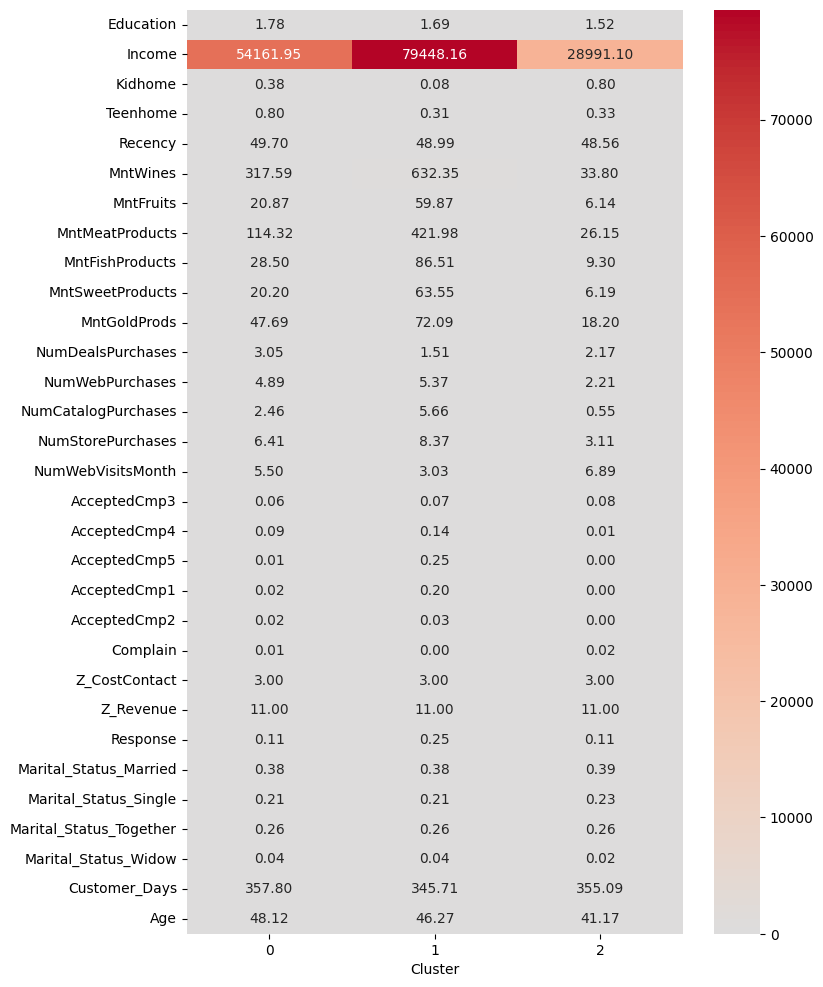

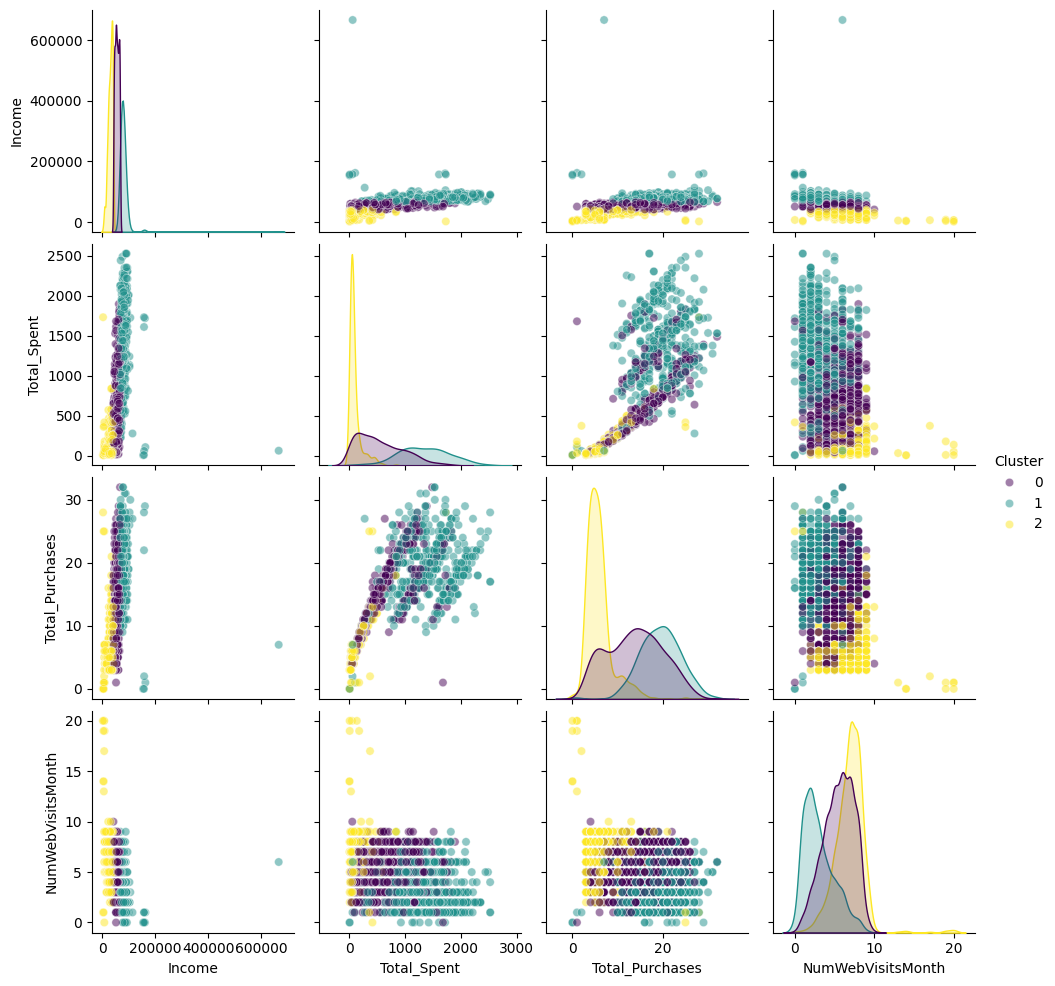

In [32]:
clustering_analysis(df, X, labels, feature_names = None, top_n = 5, plot_cols=["Income", "Total_Spent", "Total_Purchases", "NumWebVisitsMonth"])

####Висновок
Через те, що ознаки були не масштабовані - єдиною визначальною ознакою для кластеризації лишилась Income. Хоч Silhouette Coefficient = 0.54 - дані розділені погано, тільки за доходом.

**Завдання 6**. Масштабуйте дані (StandardScaler/MinMaxScaler) і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [33]:
feature_names = [c for c in df.columns
                 if c not in ["Cluster", "Total_Spent", "Total_Purchases", "Active_in_campaigns"]]

In [34]:
#Масштабування колонок
X, X_scaled = prepare(df, feature_names=feature_names, scale=True, scaler=StandardScaler)


In [35]:
X_scaled

array([[-0.79291025,  0.23569584, -0.82521765, ..., -0.18867619,
         1.53118494,  0.98534473],
       [-0.79291025, -0.23545419,  1.03255877, ..., -0.18867619,
        -1.19054458,  1.23573295],
       [-0.79291025,  0.77399892, -0.82521765, ..., -0.18867619,
        -0.20577336,  0.3176428 ],
       ...,
       [-0.79291025,  0.18947568, -0.82521765, ..., -0.18867619,
        -0.98270342, -1.01776106],
       [ 0.39831642,  0.67940139, -0.82521765, ..., -0.18867619,
        -0.97775482,  1.06880747],
       [ 1.58954309,  0.02520835,  1.03255877, ..., -0.18867619,
         1.32829237,  1.23573295]])

In [36]:
kmeans_sc = KMeans(n_clusters=3, n_init='auto', random_state=42)
labels_sc = kmeans_sc.fit_predict(X_scaled)
print(labels_sc)

[2 1 0 ... 0 0 1]


In [37]:
df["Cluster"] = labels_sc

Silhouette Coefficient for the data Dataset Clusters: 0.1358

Most influential features:



,0
MntMeatProducts,1.020424
NumCatalogPurchases,0.940831
MntFishProducts,0.885846
MntWines,0.876155
NumStorePurchases,0.863853
Income,0.846095
MntFruits,0.826842
MntSweetProducts,0.813502
NumWebVisitsMonth,0.800147
NumWebPurchases,0.789336


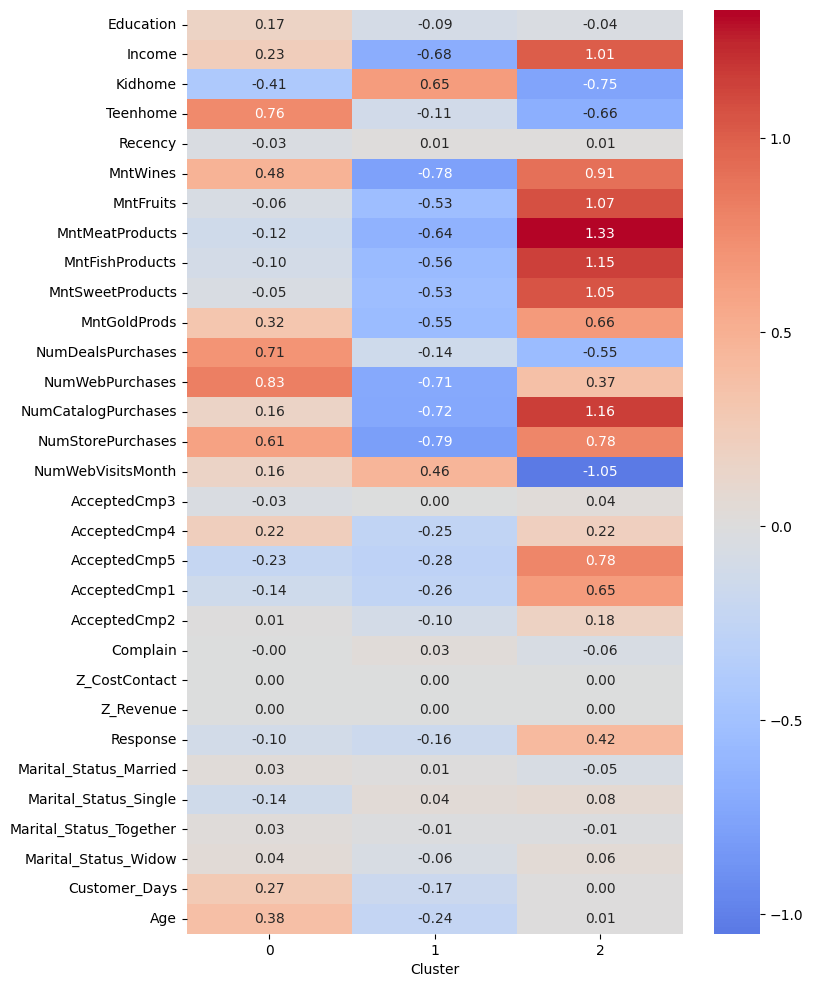

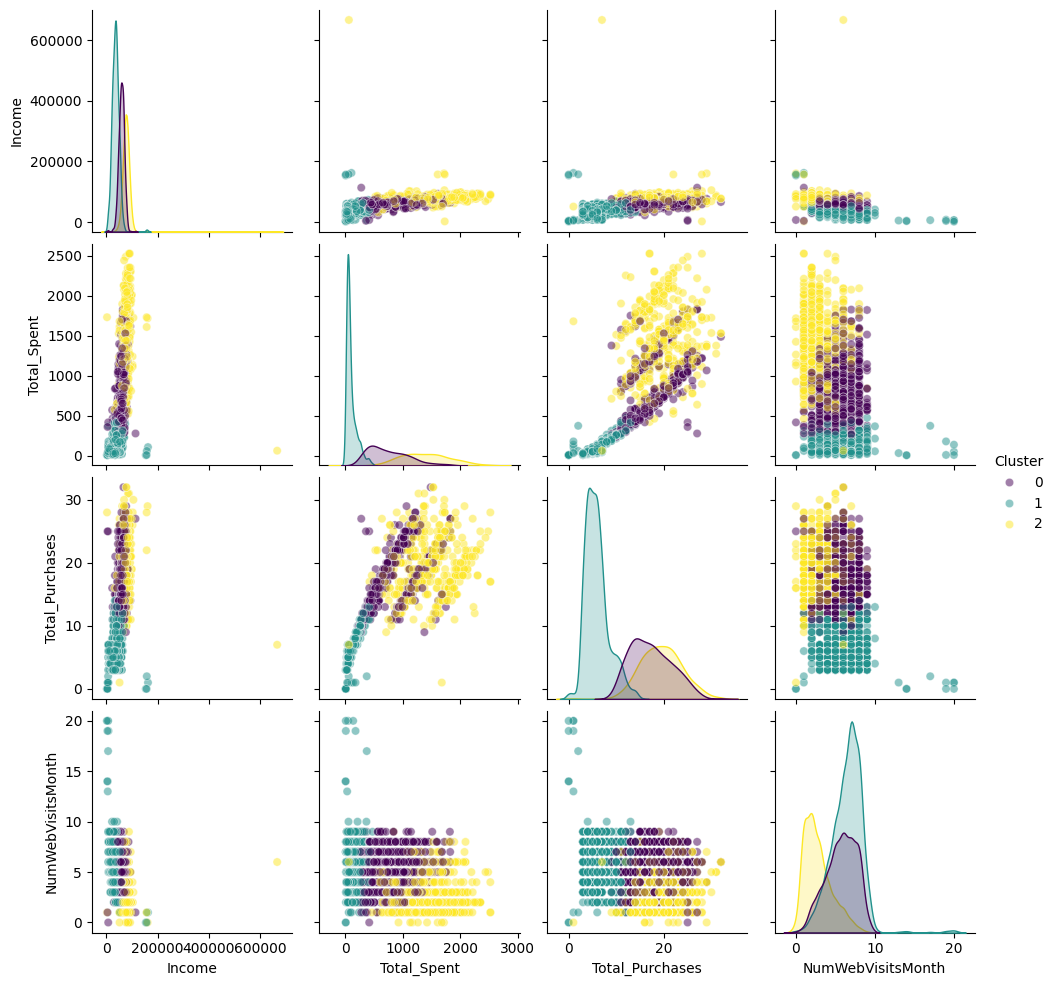

In [38]:
clustering_analysis(df, X_scaled, labels_sc, feature_names=feature_names, plot_cols=["Income", "Total_Spent", "Total_Purchases", "NumWebVisitsMonth"])

####Висновок
Після масштабування ознак, Silhouette Coefficient знизився до 0.14. Тепер помітно, що інша частина ознак теж впливає на кластеризацію (більшість з них відноситься до покупок, які робили покупці). Проте розділення все ще не чітке.

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

In [39]:
#ручне видалення викидів, які є найімовірніше помилковими даними
df = df[(df["Age"] <= 90) & (df["Income"] < 150000)].copy()


In [40]:
#IQR
def iqr_outliers(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (s < q1 - k * iqr) | (s > q3 + k * iqr)

In [41]:
continuous = ["Income", "Age", "Customer_Days", "Recency", "NumWebVisitsMonth"]
for col in continuous:
    print(col, iqr_outliers(df[col]).sum())

Income 0
Age 0
Customer_Days 0
Recency 0
NumWebVisitsMonth 8


In [42]:
df[iqr_outliers(df["NumWebVisitsMonth"])][["Income", "Total_Spent", "NumWebVisitsMonth"]]

,Income,Total_Spent,NumWebVisitsMonth
ID,,,
5899,5648.0,49,20
4303,6835.0,137,20
3955,4861.0,6,14
10749,8028.0,178,19
6862,1730.0,8,20
4246,6560.0,373,17
11110,3502.0,5,14
9931,4023.0,9,19


In [43]:
X, X_scaled = prepare(df, feature_names)

In [44]:
#Перевірка як видалення 8 аномальних рядків впливає на silhouette_score
mask = iqr_outliers(df["NumWebVisitsMonth"])

# з ними
labels_a = KMeans(3, random_state=42, n_init=10).fit_predict(X_scaled)
print(metrics.silhouette_score(X_scaled, labels_a))

# без них
X_b = X[~mask]
X_b_scaled = StandardScaler().fit_transform(X_b)
labels_b = KMeans(3, random_state=42, n_init=10).fit_predict(X_b_scaled)
print(metrics.silhouette_score(X_b_scaled, labels_b))

0.14216355291246302
0.14196018592160653


In [45]:
mask = (np.abs(stats.zscore(df[["Income", "Age"]])) > 3).any(axis=1)
df[mask]

,Education,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Customer_Days,Age,Total_Spent,Total_Purchases,Active_in_campaigns,Cluster
ID,,,,,,,,,,,,,,,,,,,,,
4619,3,113734.0,0,0,9,6,2,3,1,262,...,0.0,1.0,0.0,0.0,32,69,277,27,0,0


In [46]:
iso = IsolationForest(contamination=0.01, random_state=42)
flags = iso.fit_predict(X_scaled)

df[flags == -1]

,Education,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Customer_Days,Age,Total_Spent,Total_Purchases,Active_in_campaigns,Cluster
ID,,,,,,,,,,,,,,,,,,,,,
7215,1,101970.0,0,0,69,722,27,102,44,72,...,0.0,1.0,0.0,0.0,474,31,1135,27,4,2
2798,3,102160.0,0,0,54,763,29,138,76,176,...,0.0,0.0,1.0,0.0,604,37,1240,26,4,2
10089,1,102692.0,0,0,5,168,148,444,32,172,...,0.0,0.0,0.0,0.0,450,40,1112,28,5,2
5067,1,80134.0,0,0,11,966,26,282,52,26,...,0.0,0.0,1.0,0.0,135,20,1378,20,4,2
3725,3,84865.0,0,0,1,1248,16,349,43,16,...,0.0,1.0,0.0,0.0,416,53,1688,15,5,2
3174,1,87771.0,0,1,61,1492,38,287,50,57,...,0.0,0.0,1.0,0.0,403,55,1957,19,5,2
4611,1,105471.0,0,0,36,1009,181,104,202,21,...,0.0,0.0,1.0,0.0,524,44,1724,30,3,2
3483,1,48192.0,0,0,76,1039,43,204,153,58,...,1.0,0.0,0.0,0.0,449,56,1526,22,4,2
5536,1,87771.0,0,1,61,1492,38,287,50,57,...,0.0,0.0,1.0,0.0,403,55,1957,19,5,2


In [47]:
#колонки, по яких IsolationForest відфильтрував "аномальних" клієнтів
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names, index=df.index)

out = X_scaled_df[flags == -1].mean()
norm = X_scaled_df[flags == 1].mean()

diff = (out - norm).sort_values(key=abs, ascending=False)
diff.head(10)

,0
AcceptedCmp2,4.457020
AcceptedCmp1,3.487400
AcceptedCmp5,3.440030
AcceptedCmp4,2.382403
Response,2.037519
Income,1.732703
MntWines,1.669806
NumCatalogPurchases,1.608547
MntSweetProducts,1.432103
MntFishProducts,0.951297


In [48]:

top = diff.head(6).index
display(df.loc[flags == -1, list(top)].describe().T[["min", "50%", "max"]])
display(df.loc[flags == 1, list(top)].describe().T[["min", "50%", "max"]])

,min,50%,max
AcceptedCmp2,0.0,1.0,1.0
AcceptedCmp1,0.0,1.0,1.0
AcceptedCmp5,0.0,1.0,1.0
AcceptedCmp4,0.0,1.0,1.0
Response,0.0,1.0,1.0
Income,48192.0,87679.0,105471.0


,min,50%,max
AcceptedCmp2,0.0,0.0,1.0
AcceptedCmp1,0.0,0.0,1.0
AcceptedCmp5,0.0,0.0,1.0
AcceptedCmp4,0.0,0.0,1.0
Response,0.0,0.0,1.0
Income,1730.0,51342.0,113734.0


In [49]:
#клієнти з найбільшими відхиленнями
scores = iso.score_samples(X_scaled)
df.assign(score=scores).nsmallest(10, "score")[["Income", "Age", "Total_Spent", "score"]]

,Income,Age,Total_Spent,score
ID,,,,
10089,102692.0,40,1112,-0.654965
3138,91249.0,58,1676,-0.652133
1509,84460.0,56,523,-0.648934
3009,71670.0,52,1766,-0.641288
3725,84865.0,53,1688,-0.635711
3520,91172.0,24,1092,-0.634380
5236,77568.0,35,2194,-0.634313
4070,94871.0,45,1078,-0.629526
2798,102160.0,37,1240,-0.626814


In [50]:
#фінальна кластерізація після опрацювання викидів
X, X_scaled = prepare(df, feature_names)


kmeans_without_outliers = KMeans(n_clusters=3, n_init='auto', random_state=42)
labels_without_outliers = kmeans_without_outliers.fit_predict(X_scaled)
print(labels_without_outliers)

df["Cluster"] = labels_without_outliers

[2 0 1 ... 1 1 0]


Silhouette Coefficient for the data Dataset Clusters: 0.1425

Most influential features:



,0
MntMeatProducts,1.043774
Income,1.012536
NumCatalogPurchases,0.971890
MntFishProducts,0.887427
MntWines,0.885430
NumStorePurchases,0.871288
MntFruits,0.821108
MntSweetProducts,0.813285
NumWebVisitsMonth,0.809466
NumWebPurchases,0.790996


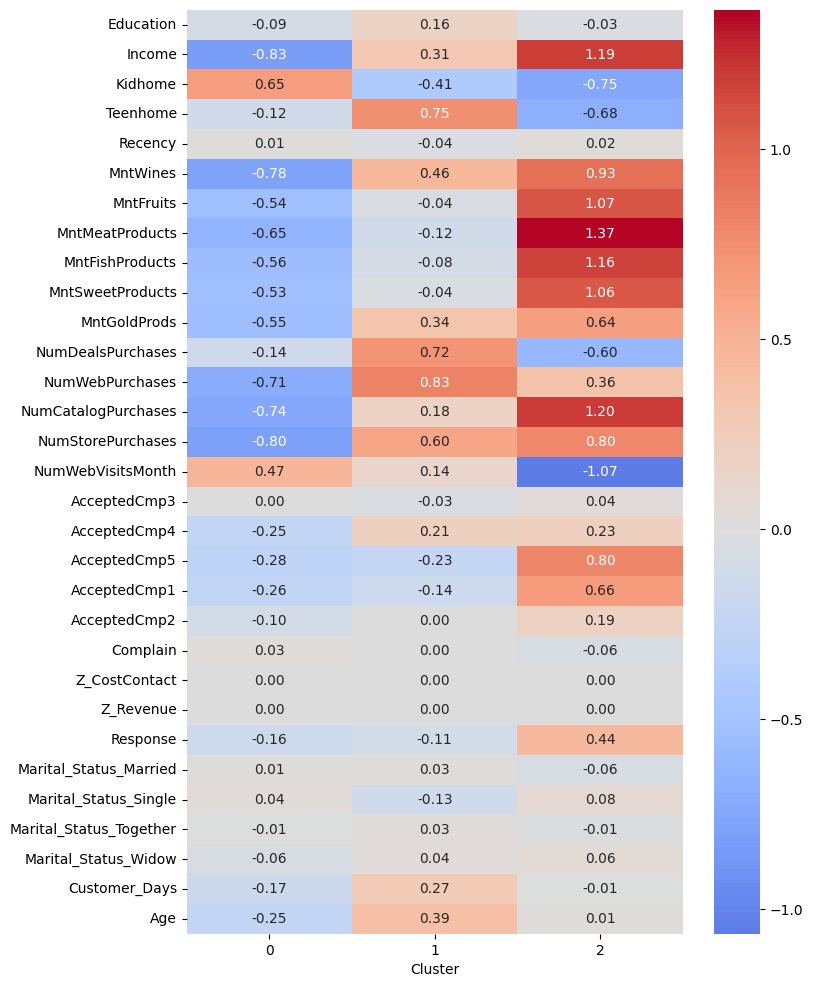

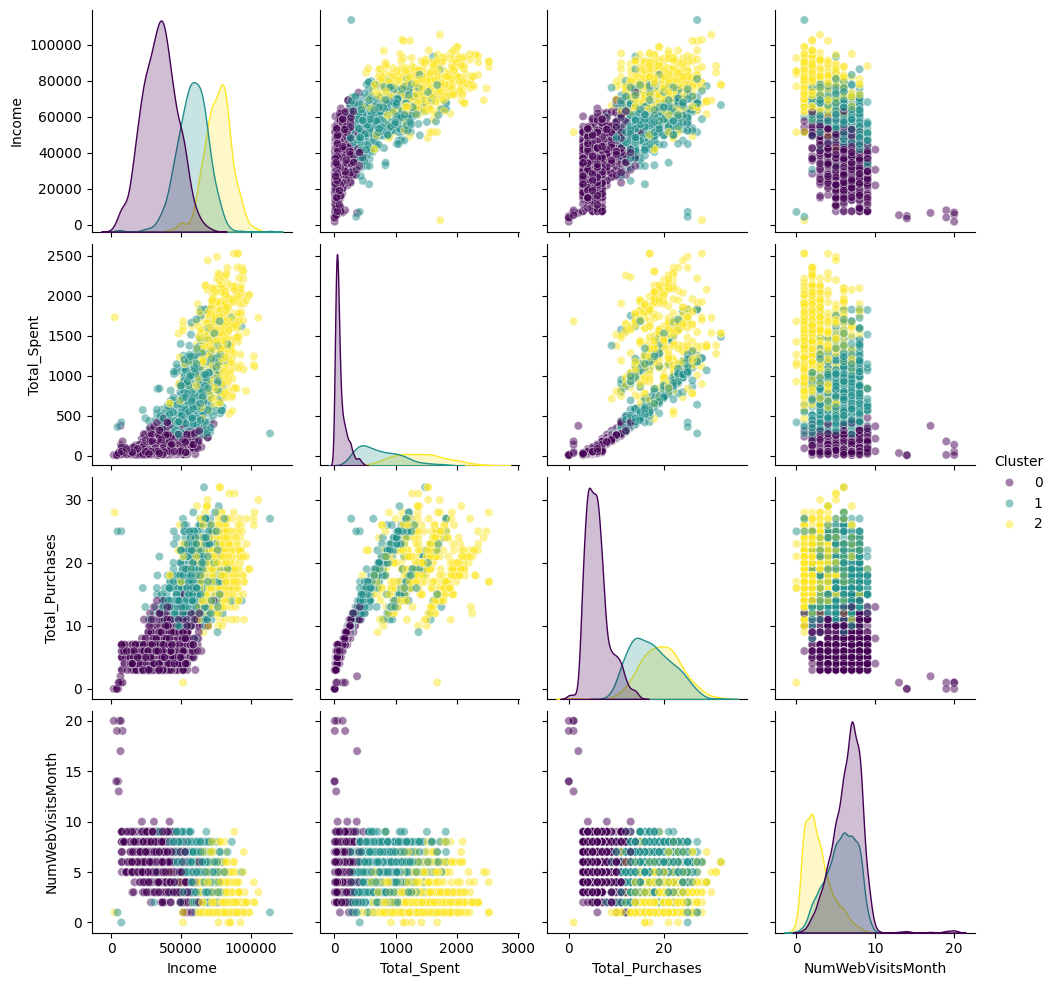

In [51]:
clustering_analysis(df, X_scaled, labels_without_outliers, feature_names, plot_cols=["Income", "Total_Spent", "Total_Purchases", "NumWebVisitsMonth"])

####Висновки
На графіках було видно аномальні викиди по Income, а також люди з віком більш ніж 90/100 років - скоріше за все теж помилики при введені даних.
IQR показав 8 рядків є аномальною поведінкою та характеристиками покупців - висока кількість відвідувань сайту NumWebVisitsMonth, дуже низький Income, дуже низькі Витрати. Після перевірки як змінюється silhouette_score при видаленні цих 8 рядків - я прийняла рішення їх лишити, бо вони мізерно впливають:
0.14216355291246302- з цими рядками
0.14196018592160653- без цих рядків


Додаткова перевірка по z-score знайшла тільки 1 значення, яке вже не є викидом. Видаляти його не буду.

Перевірка за допомогою IsolationForest знайшла окрему групу клієнтів, які активніше за інших приймають участь в акціях.

Фінальний silhouette_score не змінився після видалення outliers, проте візуально - кластери виглядають трохи чіткіше.

**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

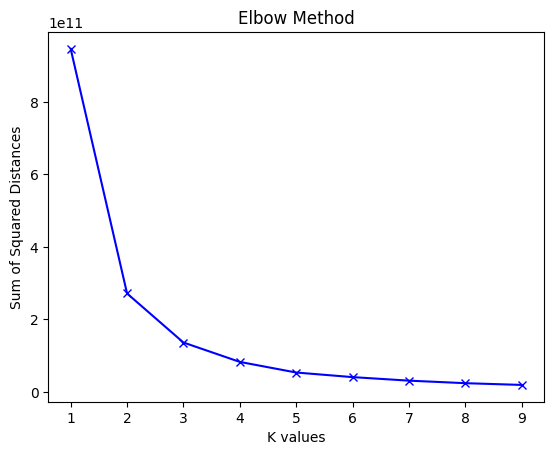

In [52]:
#на немасштабованих даних
K = range(1,10)
sum_of_squared_distances = []

for k in K:
    model = KMeans(n_clusters=k, n_init='auto', random_state=42).fit(X)
    sum_of_squared_distances.append(model.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method')
plt.show()

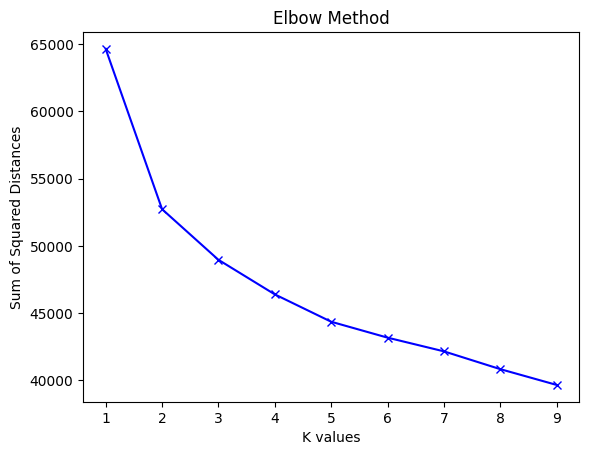

In [53]:
#на масштабованих даних
K = range(1,10)
sum_of_squared_distances = []

for k in K:
    model = KMeans(n_clusters=k, n_init='auto', random_state=42).fit(X_scaled)
    sum_of_squared_distances.append(model.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method')
plt.show()

In [54]:
for k in [2, 3, 4, 5]:
    lbl = KMeans(k, random_state=42, n_init=10).fit_predict(X_scaled)
    print(k, round(metrics.silhouette_score(X_scaled, lbl), 3))

2 0.212
3 0.142
4 0.14
5 0.145


In [55]:
#кластерізація після видалення викидів з 4ма кластерами
X, X_scaled = prepare(df, feature_names)


kmeans_without_outliers_4 = KMeans(n_clusters=4, n_init='auto', random_state=42)
labels_without_outliers_4 = kmeans_without_outliers_4.fit_predict(X_scaled)
print(labels_without_outliers_4)

df["Cluster"] = labels_without_outliers_4

[2 3 2 ... 0 0 3]


Silhouette Coefficient for the data Dataset Clusters: 0.1404

Most influential features:



,0
AcceptedCmp5,1.832197
MntWines,1.017340
Income,1.011893
MntMeatProducts,1.000943
NumCatalogPurchases,0.921931
MntFishProducts,0.829598
AcceptedCmp1,0.821654
MntSweetProducts,0.800952
MntFruits,0.788186
NumWebVisitsMonth,0.772303


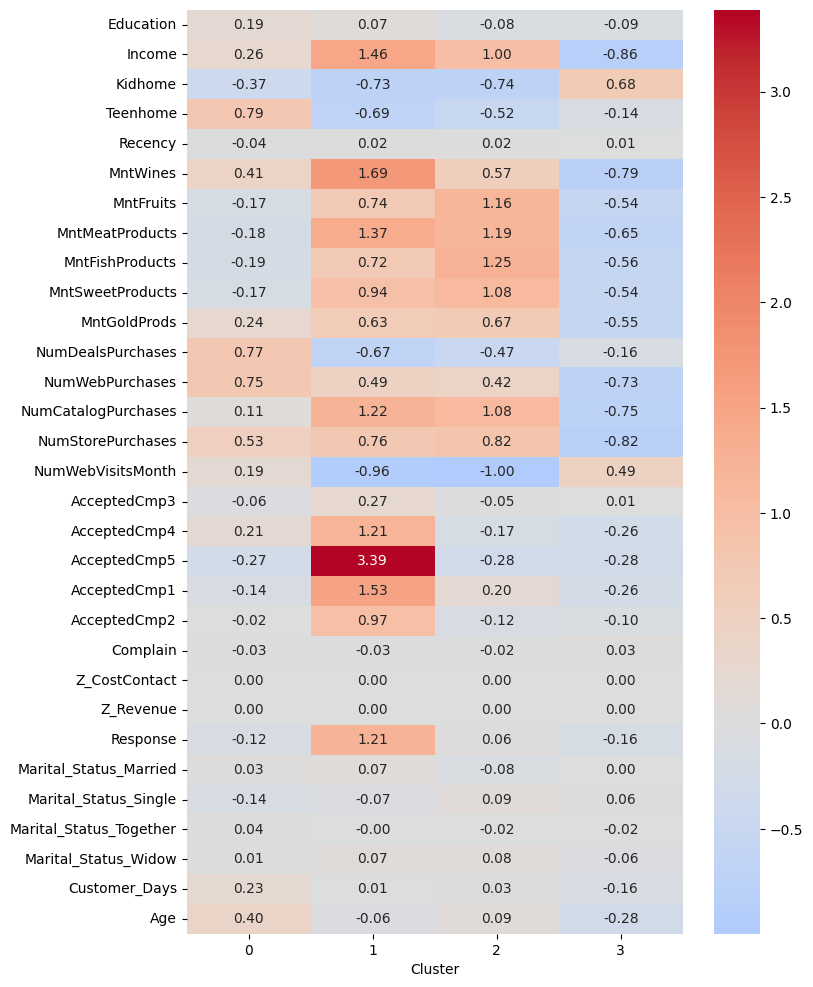

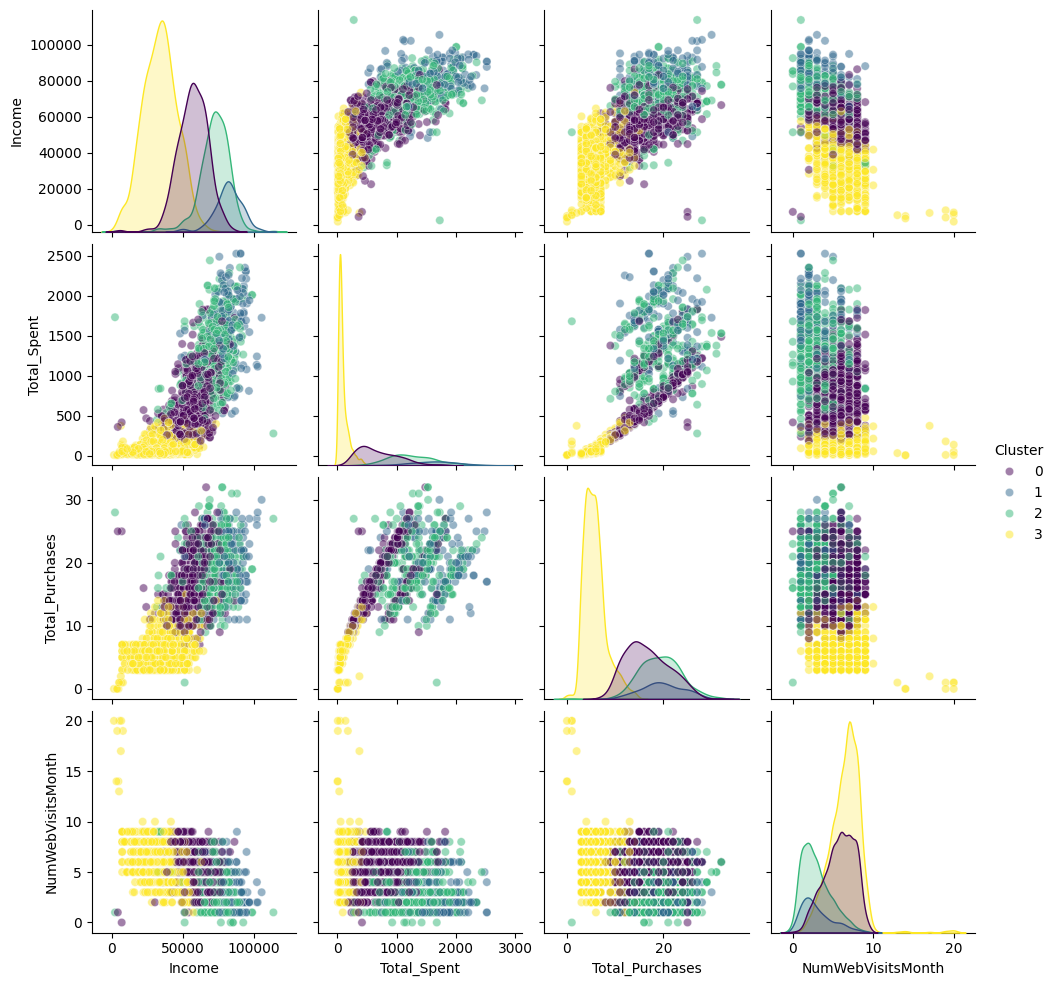

In [56]:
clustering_analysis(df, X_scaled, labels_without_outliers_4, feature_names, plot_cols=["Income", "Total_Spent", "Total_Purchases", "NumWebVisitsMonth"])

####Висновки
З графіків метода Ліктя можемо зробити висновок, що оптимальний k для цих даних 3 або 4. Дані краще брати масштабовані, інакше - графік покаже оптимальний розподіл суто по Income.
З 4ма кластерами дані ще більше перемішуються, тому візуально все ж з 3ма кластерами виглядає краще

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

In [57]:
X, X_scaled = prepare(df, feature_names=feature_names, scale=True, scaler=StandardScaler)

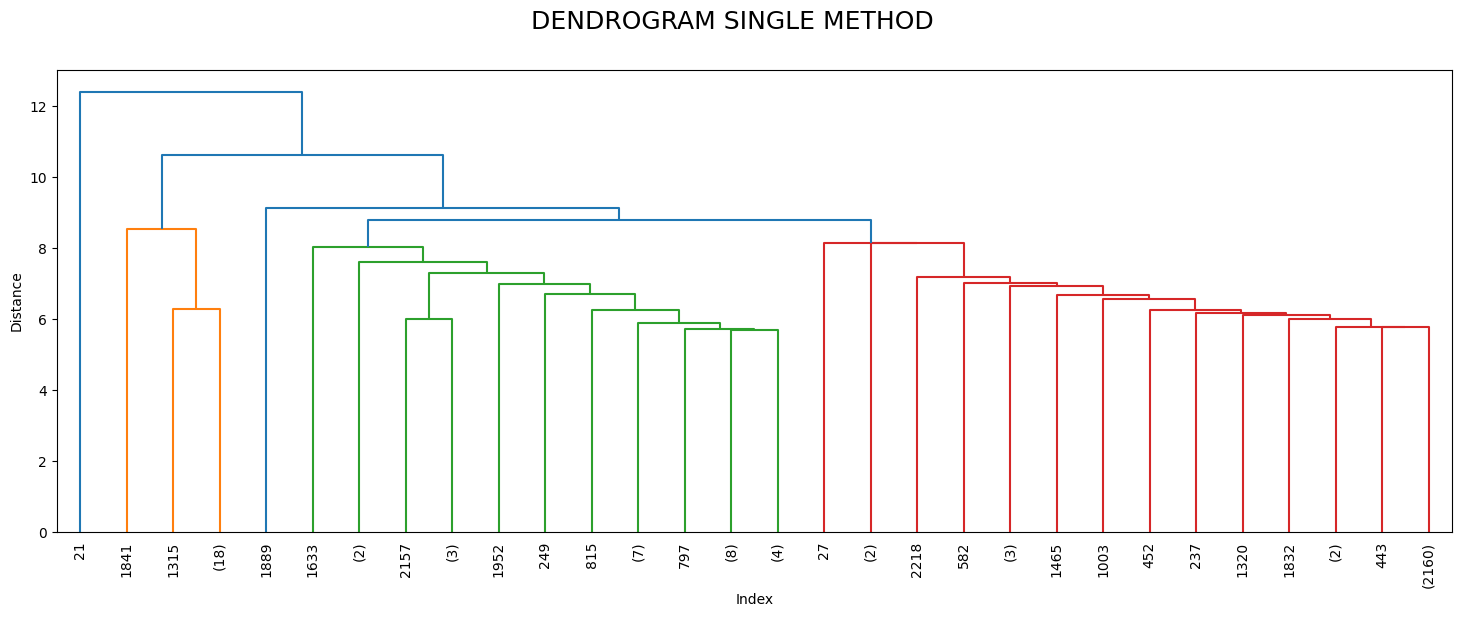

In [58]:
#9.1, 9.2 Single linkage
dist_sin = linkage(X_scaled, method="single")
plt.figure(figsize=(18,6))
dendrogram(dist_sin, leaf_rotation=90, truncate_mode='lastp')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("DENDROGRAM SINGLE METHOD",fontsize=18)
plt.show()

In [59]:
#9.3, 9.4
for k in [2, 3]:
    lbl = fcluster(dist_sin, k, criterion="maxclust")
    print(k, np.bincount(lbl)[1:])
    print("  silhouette:", round(metrics.silhouette_score(X_scaled, lbl), 3))

2 [2228    1]
  silhouette: 0.522
3 [  20 2208    1]
  silhouette: 0.441


In [60]:
#переглядаємо чим вирізняються рядки, що попали в 3й кластер
lbl_sc = fcluster(dist_sin, 3, criterion="maxclust")
df[lbl_sc == 1][["Income", "Total_Spent", "Total_Purchases", "NumWebVisitsMonth", "Age"]].describe()

,Income,Total_Spent,Total_Purchases,NumWebVisitsMonth,Age
count,20.000000,20.000000,20.000000,20.00000,20.000000
mean,45672.400000,392.000000,11.200000,5.85000,45.650000
std,19618.595911,437.239787,8.160237,2.41214,15.044758
min,15716.000000,11.000000,3.000000,1.00000,19.000000
25%,36277.500000,52.750000,5.000000,4.50000,34.500000
50%,39341.000000,95.500000,7.000000,7.00000,44.000000
75%,59853.000000,667.250000,16.500000,8.00000,59.250000
max,83257.000000,1365.000000,27.000000,9.00000,71.000000


In [61]:
#переглядаємо чим вирізняються рядки, що попали в 3й кластер
grp = df[lbl_sc == 1]
rest = df[lbl_sc == 2]

comp = pd.DataFrame({
    "група_20": grp[feature_names].mean(),
    "решта": rest[feature_names].mean()
})
comp["різниця"] = (comp["група_20"] - comp["решта"]).abs()
comp.sort_values("різниця", ascending=False).head(10)

,група_20,решта,різниця
Income,45672.40,51695.643116,6023.243116
MntWines,176.70,306.291214,129.591214
Customer_Days,429.70,353.005888,76.694112
MntMeatProducts,117.70,165.008605,47.308605
MntGoldProds,27.60,44.282156,16.682156
MntFishProducts,26.70,37.758152,11.058152
MntSweetProducts,18.20,27.254529,9.054529
Recency,50.75,49.094656,1.655344
MntFruits,25.10,26.371377,1.271377
Complain,1.00,0.000000,1.000000


Silhouette Coefficient for the data Dataset Clusters: 0.4410

Most influential features:



,0
Complain,6.122610
NumCatalogPurchases,5.295143
MntMeatProducts,4.170893
NumDealsPurchases,3.852458
Income,1.304308
NumWebVisitsMonth,1.102999
NumStorePurchases,1.001218
NumWebPurchases,0.815314
Marital_Status_Married,0.719993
Teenhome,0.561773


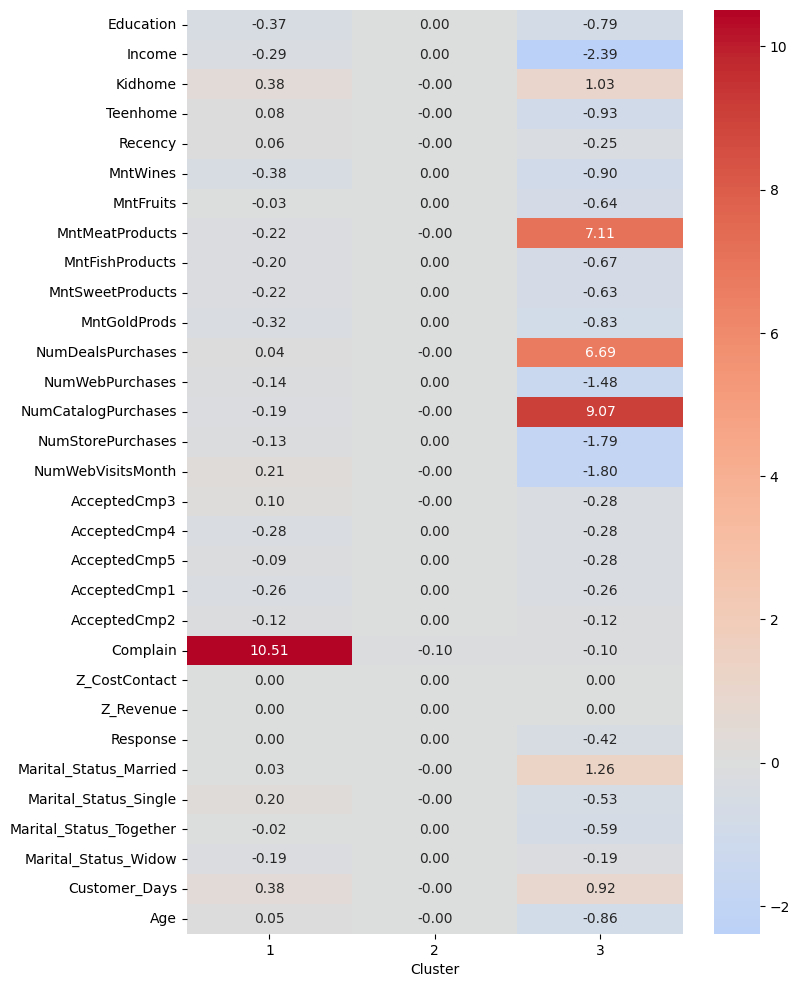

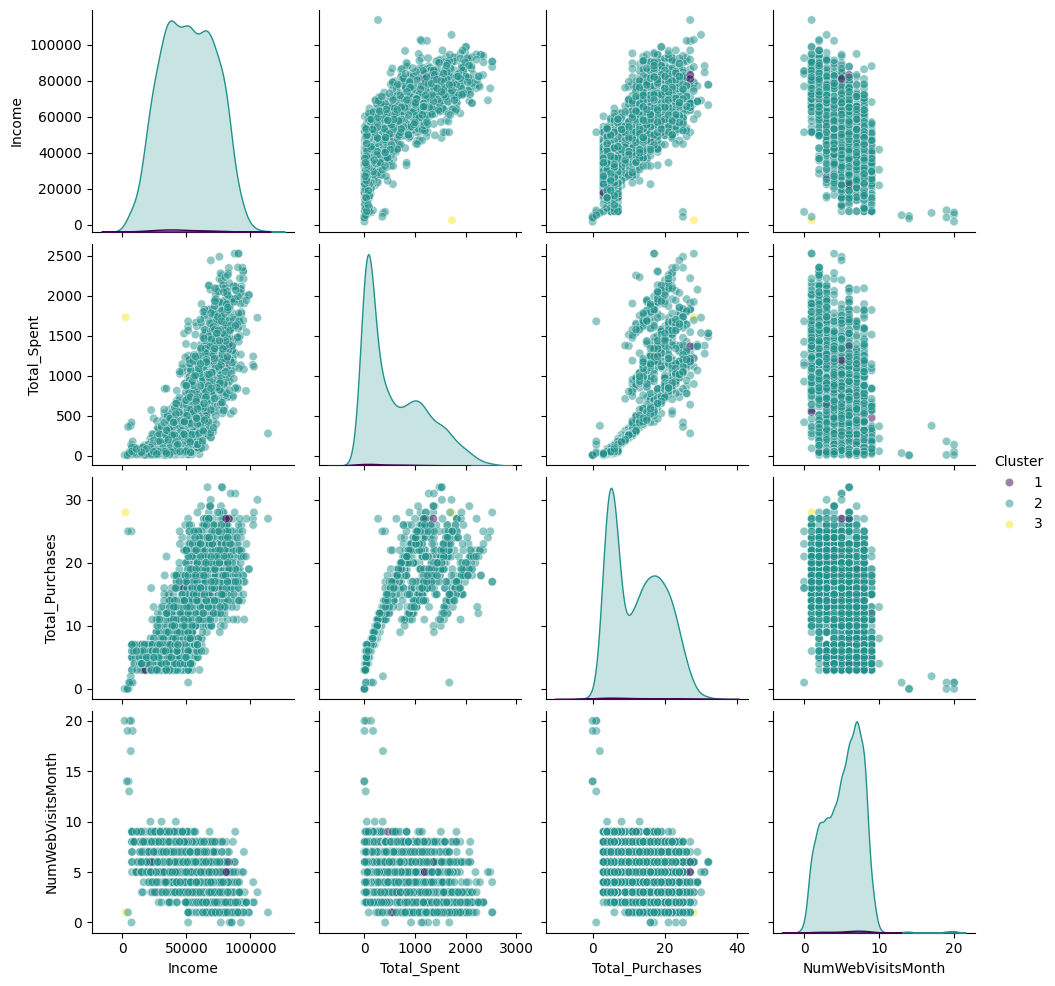

In [62]:
df["Cluster"] = fcluster(dist_sin, 3, criterion="maxclust")
clustering_analysis(df, X_scaled, df["Cluster"], feature_names, plot_cols=["Income", "Total_Spent", "Total_Purchases", "NumWebVisitsMonth"])

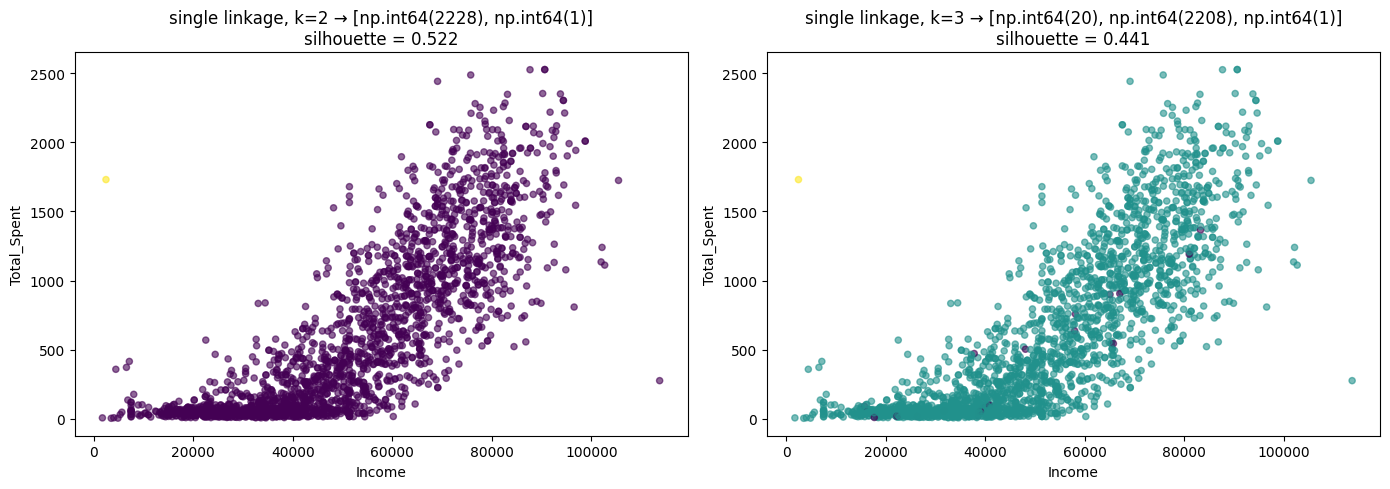

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, k in zip(axes, [2, 3]):
    lbl = fcluster(dist_sin, k, criterion="maxclust")
    sizes = np.bincount(lbl)[1:]

    sc = ax.scatter(df["Income"], df["Total_Spent"], c=lbl,
                    cmap="viridis", alpha=0.6, s=20)
    ax.set_xlabel("Income"); ax.set_ylabel("Total_Spent")
    ax.set_title(f"single linkage, k={k} → {list(sizes)}\n"
                 f"silhouette = {metrics.silhouette_score(X_scaled, lbl):.3f}")

plt.tight_layout()

####Висновок
Я спробувала давати в ієрархічну агломеративну кластеризацію з single linkage дані без скейлингу та зі скейлингом. У випадку без скейлингу -  воно вважає одиним класом якусь віддалену точку, а все інше складає в другий клас. Зі скейлингом хоч якось будується дендрограма із більш ніж 1 класом, окремо виділяється група із 20 рядків. Проте - ця група виділяється на фоні відмінності в одній бінарній ознаці, що не характеризує покупця.
При цьому silhouette score виходить доволі високий, і для 2х, і дял 3х кластерів, що не має особливо сенсу, якщо подивитись на scatter plot
 2 [2228    1]
  silhouette: 0.522
3 [  20 2208    1]
  silhouette: 0.441

Можливо варто виключити бінарні ознаки з навчання або об"єднати їх групами в сукупні ознаки.

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте мер=трику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

In [64]:
X, X_scaled = prepare(df, feature_names=feature_names, scale=True, scaler=StandardScaler)

In [65]:
dbscan = DBSCAN(eps=7, min_samples=10)
dbscan.fit(X_scaled)
labels = dbscan.labels_
print(np.unique(labels, return_counts=True))

(array([-1,  0,  1,  2]), array([  18, 2170,   19,   22]))


In [66]:
for eps in [2, 3, 4, 5, 6, 7]:
    lbl = DBSCAN(eps=eps, min_samples=10).fit_predict(X_scaled)
    n_clusters = len(set(lbl)) - (1 if -1 in lbl else 0)
    n_noise = (lbl == -1).sum()
    print(f"eps={eps}: кластерів={n_clusters}, шум={n_noise}")

eps=2: кластерів=9, шум=1726
eps=3: кластерів=2, шум=1024
eps=4: кластерів=2, шум=463
eps=5: кластерів=3, шум=194
eps=6: кластерів=2, шум=57
eps=7: кластерів=3, шум=18


In [67]:
for eps in [3, 4, 5, 6, 7]:
  lbl = DBSCAN(eps=eps, min_samples=10).fit_predict(X_scaled)
  sizes = np.bincount(lbl[lbl != -1]) if (lbl != -1).any() else []
  m = lbl != -1
  sil = (metrics.silhouette_score(X_scaled[m], lbl[m])
      if len(set(lbl[m])) > 1 else None)
  print(f"eps={eps}: розміри={list(sizes)}, шум={(lbl==-1).sum()}, silhouette={sil}")

eps=3: розміри=[np.int64(1194), np.int64(11)], шум=1024, silhouette=0.3006946128812946
eps=4: розміри=[np.int64(1729), np.int64(37)], шум=463, silhouette=0.24018125523390269
eps=5: розміри=[np.int64(1970), np.int64(53), np.int64(12)], шум=194, silhouette=0.22715074354089249
eps=6: розміри=[np.int64(2155), np.int64(17)], шум=57, silhouette=0.44767288707033204
eps=7: розміри=[np.int64(2170), np.int64(19), np.int64(22)], шум=18, silhouette=0.4273562847662267


In [68]:
lbl2 = DBSCAN(eps=7, min_samples=10).fit_predict(X_scaled)
print(np.bincount(lbl2[lbl2 != -1]))

df.assign(c=lbl2).groupby("c")[["Income", "Total_Spent", "Complain",
                                "Marital_Status_Single", "Kidhome"]].mean().round(2)

[2170   19   22]


,Income,Total_Spent,Complain,Marital_Status_Single,Kidhome
c,,,,,
-1,52679.11,1022.33,0.06,0.28,0.28
0,51474.06,597.10,0.00,0.22,0.45
1,43694.26,340.79,1.00,0.26,0.68
2,71943.05,1326.14,0.00,0.18,0.00


Silhouette Coefficient for the data Dataset Clusters: 0.4207

Most influential features:



,0
Complain,5.211550
AcceptedCmp2,4.119322
AcceptedCmp4,1.709365
MntWines,1.029182
AcceptedCmp5,0.986272
AcceptedCmp3,0.888899
AcceptedCmp1,0.826741
MntGoldProds,0.714099
Response,0.709656
NumWebPurchases,0.708523


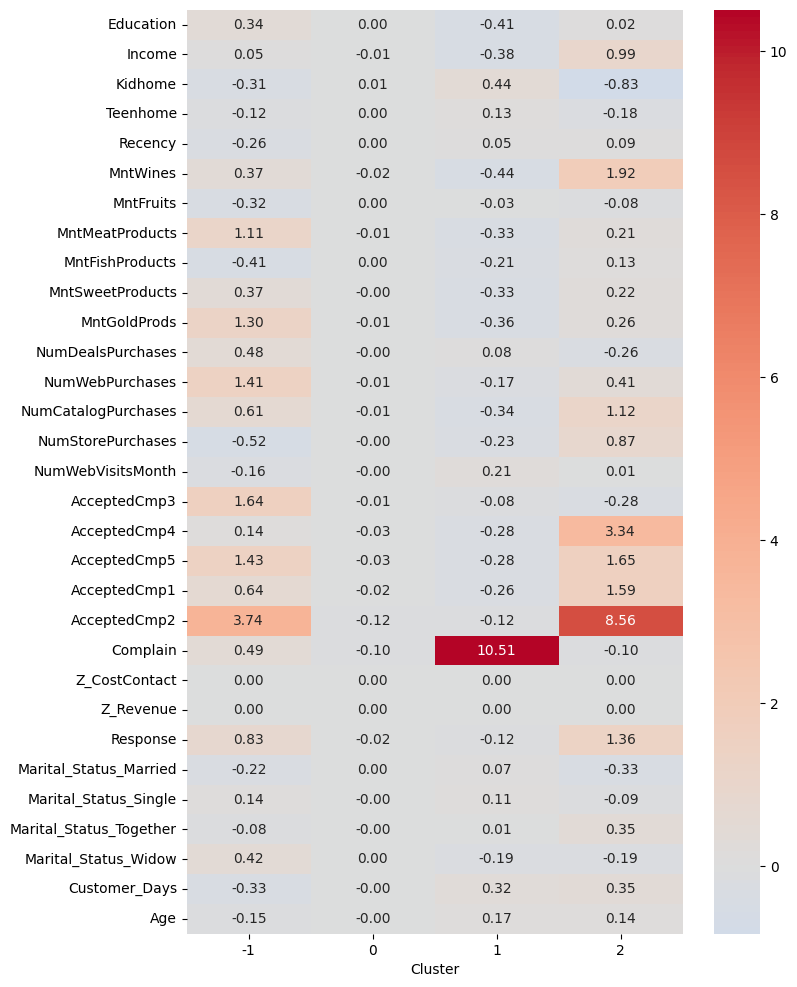

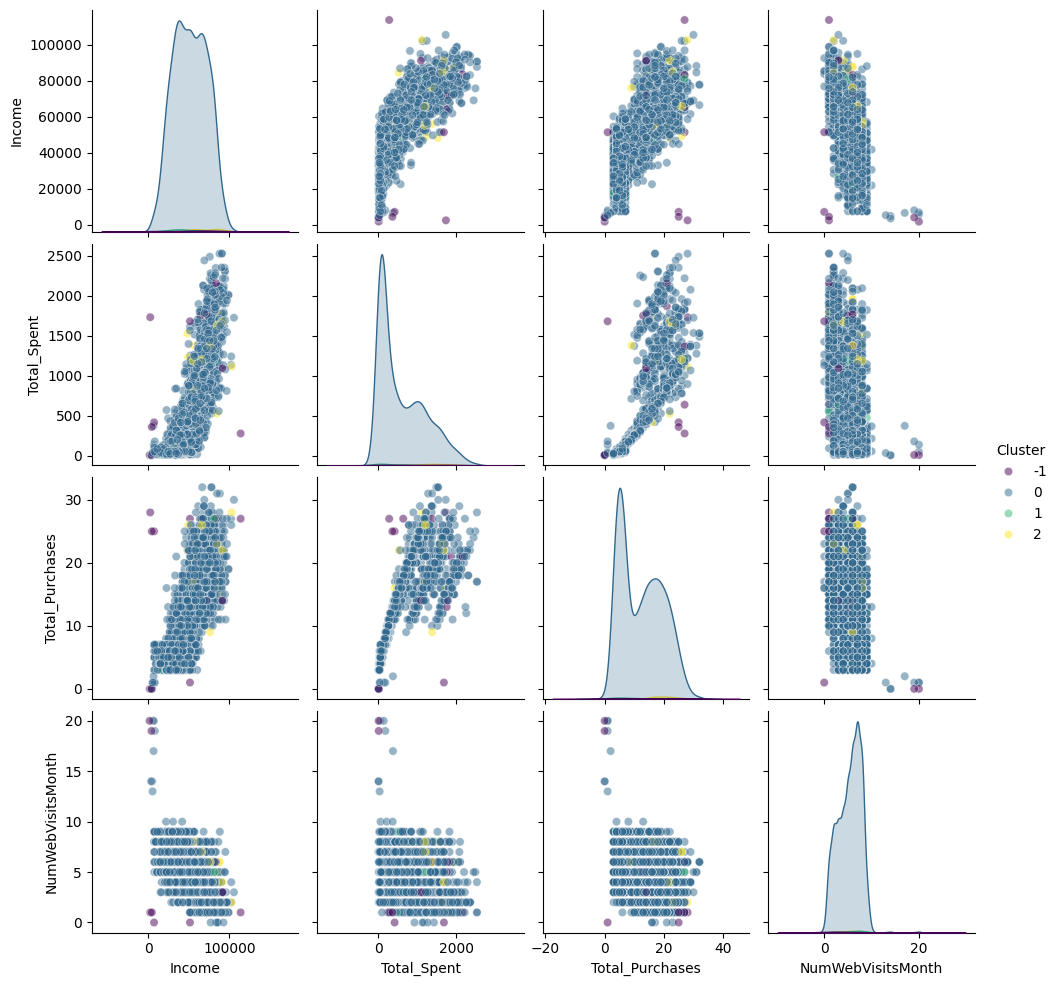

In [69]:
lbl = DBSCAN(eps=7, min_samples=10).fit_predict(X_scaled)

df["Cluster"] = lbl
clustering_analysis(df, X_scaled, lbl, feature_names, plot_cols=["Income", "Total_Spent", "Total_Purchases", "NumWebVisitsMonth"])

####Висновки
DBSCAN зосередився на бінарних ознаках та створив кластери на основі їх унікальних комбінацій, а також відніс до шуму більшість активних клієнтів. Виходить, що dbscan більше підійшов би для аналізу аномалій, а не кластеризації.

###Додаткові експерименти
В якості додаткового експерименту хочу зменшити кількість ознак - видаливши константи та об"єднавши в більші категорії бінарні

In [70]:
spend_cols = ["MntWines", "MntFruits", "MntMeatProducts",
              "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
purch_cols = ["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]
campaign_cols = ["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3",
                 "AcceptedCmp4", "AcceptedCmp5", "Response"]
const_cols = ["Z_CostContact", "Z_Revenue"]

kids_cols = ["Kidhome", "Teenhome"]
df["Children"] = df[kids_cols].sum(axis=1)

df["Avg_Check"] = (df["Total_Spent"] / df["Total_Purchases"].replace(0, np.nan)).fillna(0)

df["Has_Partner"] = (df["Marital_Status_Married"] + df["Marital_Status_Together"]).astype(int)
marital_cols = [c for c in df.columns if c.startswith("Marital_Status_")]


feature_names_14 = [c for c in df.columns
                    if c not in spend_cols + purch_cols + campaign_cols
                    + const_cols + marital_cols + kids_cols + ["Cluster"]]
print(len(feature_names_14), feature_names_14)

X, X_scaled = prepare(df, feature_names_14)
for k in [2, 3, 4, 5]:
    lbl = KMeans(k, random_state=42, n_init=10).fit_predict(X_scaled)
    print(k, round(metrics.silhouette_score(X_scaled, lbl), 3))

14 ['Education', 'Income', 'Recency', 'NumDealsPurchases', 'NumWebVisitsMonth', 'Complain', 'Customer_Days', 'Age', 'Total_Spent', 'Total_Purchases', 'Active_in_campaigns', 'Children', 'Avg_Check', 'Has_Partner']
2 0.222
3 0.231
4 0.161
5 0.17


<Axes: >

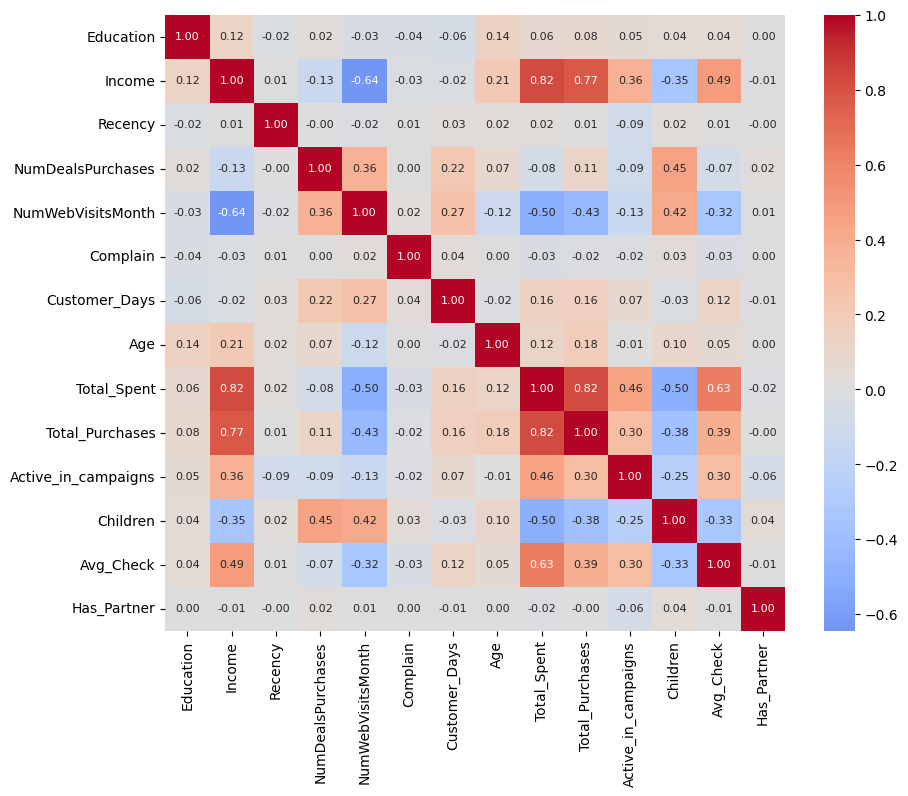

In [71]:
corr = df[feature_names_14].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 8})

In [72]:
pairs = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
pairs.sort_values(ascending=False).head(10)

Income             Total_Spent            0.820222
Total_Spent        Total_Purchases        0.820206
Income             Total_Purchases        0.774520
                   NumWebVisitsMonth      0.644405
Total_Spent        Avg_Check              0.629647
NumWebVisitsMonth  Total_Spent            0.503035
Total_Spent        Children               0.499513
Income             Avg_Check              0.490166
Total_Spent        Active_in_campaigns    0.457727
NumDealsPurchases  Children               0.452311
dtype: float64

In [73]:
base = round(metrics.silhouette_score(
    X_scaled, KMeans(3, random_state=42, n_init=10).fit_predict(X_scaled)), 4)
print("базовий:", base, "\n")

results = {}
for col in feature_names_14:
    feats = [c for c in feature_names_14 if c != col]
    _, Xs = prepare(df, feats)
    s = metrics.silhouette_score(Xs, KMeans(3, random_state=42, n_init=10).fit_predict(Xs))
    results[col] = round(s - base, 4)

pd.Series(results).sort_values(ascending=False)

базовий: 0.2311 



,0
Customer_Days,0.0185
Active_in_campaigns,0.0074
Avg_Check,-0.0095
Total_Spent,-0.0338
Age,-0.0486
Has_Partner,-0.0497
Recency,-0.0507
Education,-0.0525
Children,-0.0621
Complain,-0.0629


In [74]:
for drop in [["Customer_Days"], ["Customer_Days", "Active_in_campaigns"]]:
    feats = [c for c in feature_names_14 if c not in drop]
    _, Xs = prepare(df, feats)
    row = [round(metrics.silhouette_score(Xs, KMeans(k, random_state=42, n_init=10).fit_predict(Xs)), 3)
           for k in [2, 3, 4]]
    print(f"{len(feats)} ознак, без {drop}: {row}")

13 ознак, без ['Customer_Days']: [np.float64(0.24), np.float64(0.25), np.float64(0.184)]
12 ознак, без ['Customer_Days', 'Active_in_campaigns']: [np.float64(0.249), np.float64(0.192), np.float64(0.202)]


Silhouette Coefficient for the data Dataset Clusters: 0.2496

Most influential features:



,0
Complain,6.122610
Total_Spent,0.912666
Income,0.845923
Total_Purchases,0.841890
NumWebVisitsMonth,0.609199
Children,0.572208
Avg_Check,0.565837
Active_in_campaigns,0.360703
Education,0.230589
NumDealsPurchases,0.201281


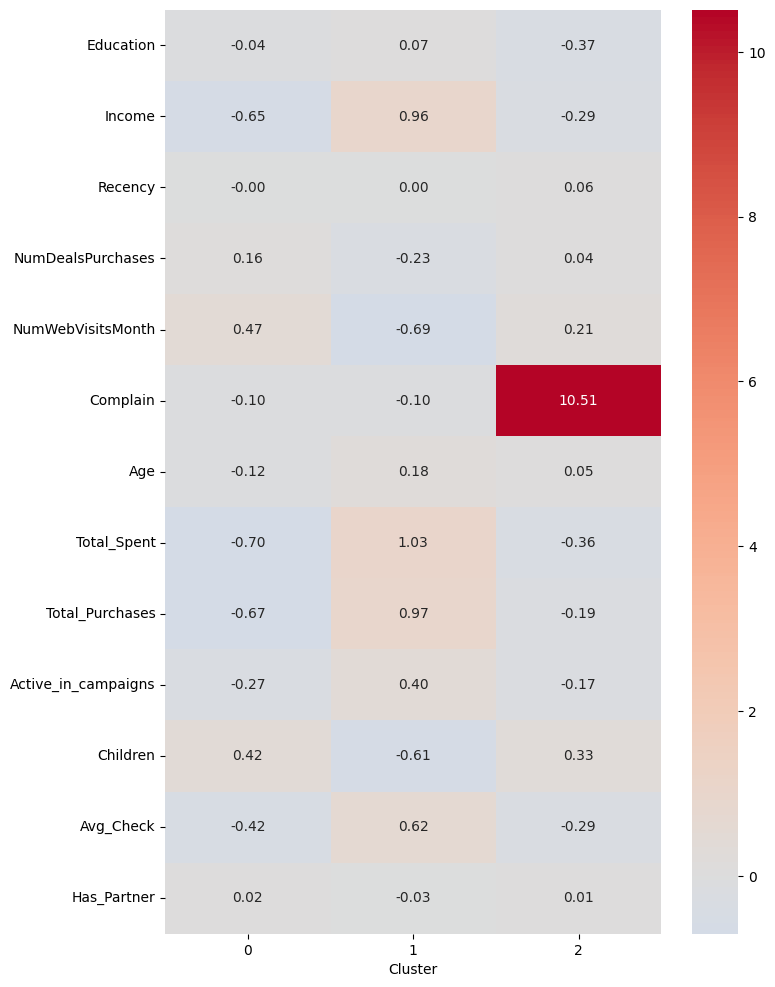

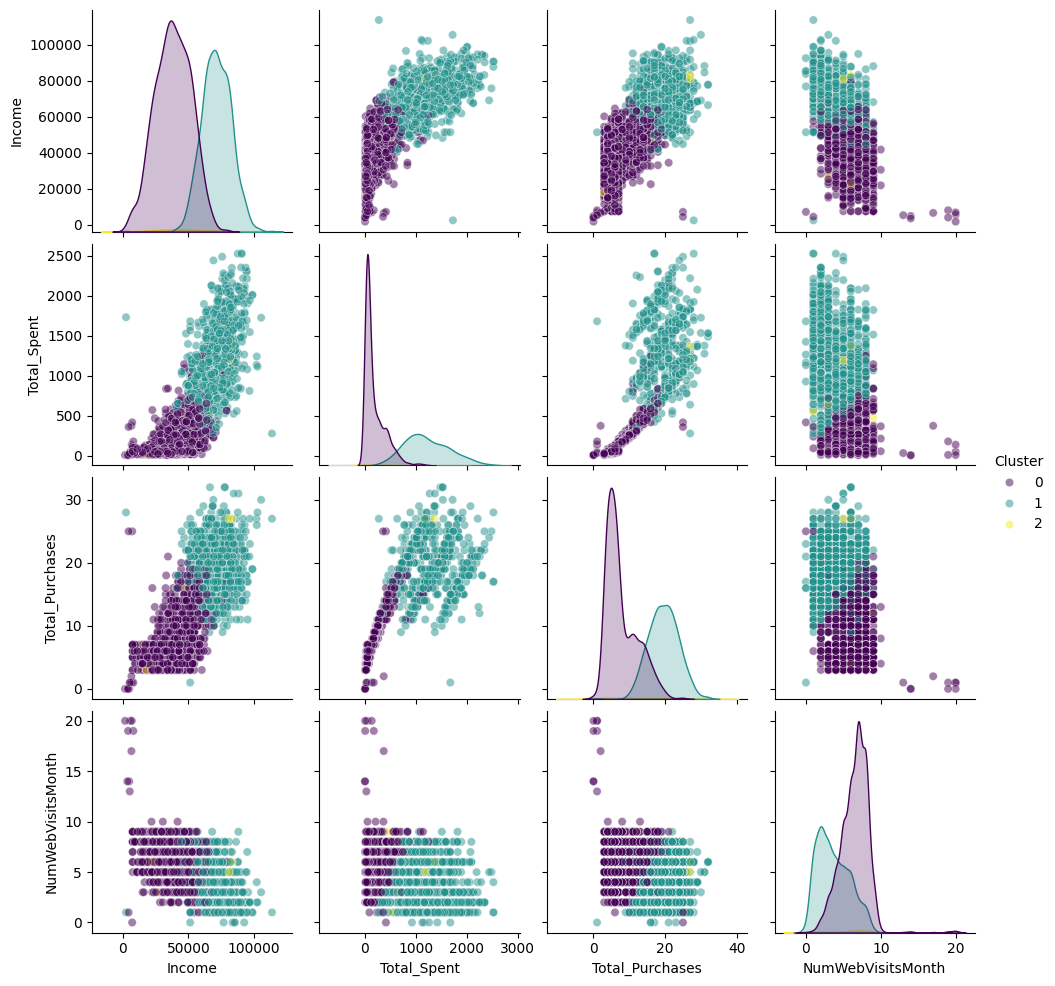

Cluster,0,1,2
Income,38179.000000,71120.500000,39341.00
Total_Spent,90.000000,1166.000000,95.50
Total_Purchases,6.000000,20.000000,7.00
Has_Partner,1.000000,1.000000,1.00
Complain,0.000000,0.000000,1.00
Education,1.000000,1.000000,1.00
Recency,49.000000,50.000000,48.50
Avg_Check,15.333333,67.666667,16.35
Age,42.000000,47.000000,44.00
Children,1.000000,0.000000,1.00


In [75]:
feature_names_final = [c for c in feature_names_14 if c != "Customer_Days"]

X, X_scaled = prepare(df, feature_names_final)
labels_final = KMeans(3, random_state=42, n_init=10).fit_predict(X_scaled)
df["Cluster"] = labels_final

clustering_analysis(df, X_scaled, labels_final, feature_names_final, plot_cols=["Income", "Total_Spent", "Total_Purchases", "NumWebVisitsMonth"])

df.groupby("Cluster")[["Income", "Total_Spent", "Total_Purchases","Has_Partner", "Complain", "Education", "Recency", "Avg_Check",
                       "Age", "Children", "NumWebVisitsMonth",
                       "NumDealsPurchases", "Active_in_campaigns"]].median().T

In [76]:
feature_names_last = [c for c in df.columns
                       if c not in spend_cols + purch_cols + campaign_cols
                       + const_cols + marital_cols + kids_cols
                       + ["Cluster", "Customer_Days", "Complain"]]

X, X_scaled = prepare(df, feature_names_last)
for k in [2, 3, 4]:
    lbl = KMeans(k, random_state=42, n_init=10).fit_predict(X_scaled)
    print(k, round(metrics.silhouette_score(X_scaled, lbl), 3),
          np.bincount(lbl))


2 0.246 [1321  908]
3 0.178 [ 642  567 1020]
4 0.182 [1012  608  209  400]


In [77]:
for k in [3, 4]:
    lbl = KMeans(k, random_state=42, n_init=10).fit_predict(X_scaled)
    df["Cluster"] = lbl
    print(f"\n=== k={k} ===")
    display(df.groupby("Cluster")[["Income", "Total_Spent", "Total_Purchases", "Avg_Check",
                                   "Age", "Children", "NumWebVisitsMonth",
                                   "NumDealsPurchases", "Active_in_campaigns"]].median().T)


=== k=3 ===


Cluster,0,1,2
Income,57958.000000,76618.000000,34378.50
Total_Spent,661.000000,1364.000000,63.00
Total_Purchases,17.000000,19.000000,5.00
Avg_Check,36.730952,71.384615,12.25
Age,49.000000,45.000000,41.00
Children,1.000000,0.000000,1.00
NumWebVisitsMonth,6.000000,2.000000,7.00
NumDealsPurchases,4.000000,1.000000,2.00
Active_in_campaigns,0.000000,1.000000,0.00



=== k=4 ===


Cluster,0,1,2,3
Income,34416.50,69681.5000,81246.00,53860.500000
Total_Spent,63.00,1033.0000,1685.00,561.500000
Total_Purchases,5.00,19.0000,19.00,15.000000
Avg_Check,12.25,49.3125,94.95,34.789474
Age,41.00,49.0000,42.00,48.000000
Children,1.00,0.0000,0.00,1.000000
NumWebVisitsMonth,7.00,3.0000,3.00,7.000000
NumDealsPurchases,2.00,1.0000,1.00,5.000000
Active_in_campaigns,0.00,0.0000,2.00,0.000000


Silhouette Coefficient for the data Dataset Clusters: 0.1781

Most influential features:



,0
Total_Spent,1.066945
Income,1.013657
Total_Purchases,0.994391
NumWebVisitsMonth,0.816010
Children,0.813960
NumDealsPurchases,0.804454
Avg_Check,0.687806
Active_in_campaigns,0.559677
Age,0.308609
Education,0.141572


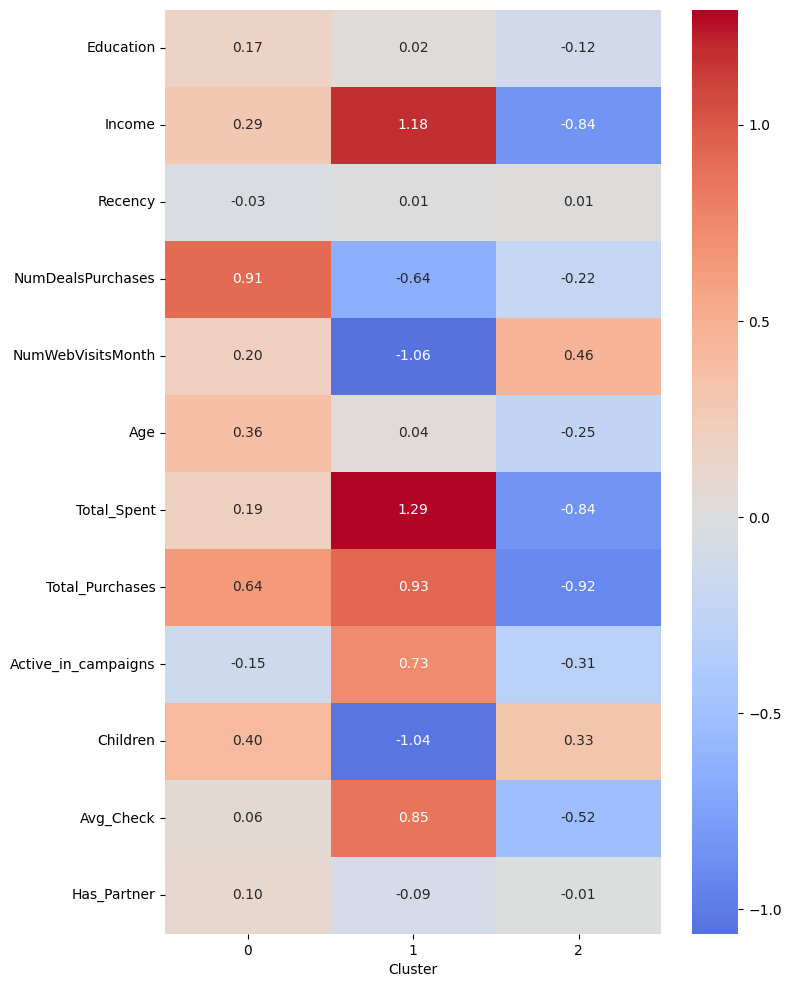

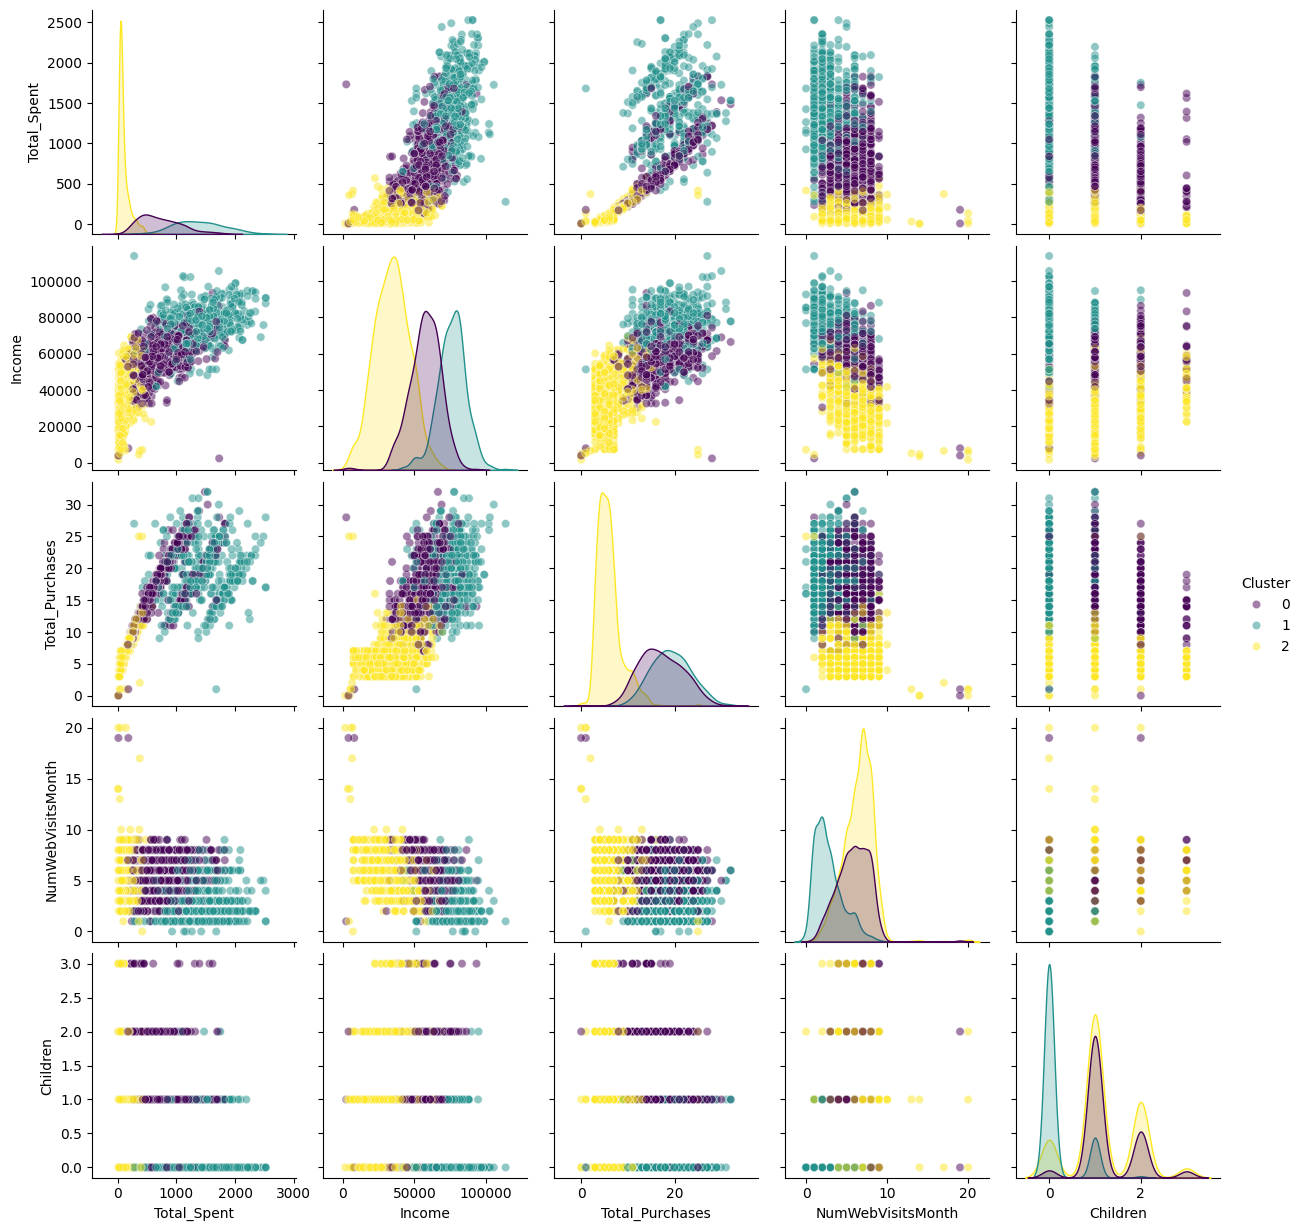

In [78]:
lbl = KMeans(3, random_state=42, n_init=10).fit_predict(X_scaled)
df["Cluster"] = lbl
clustering_analysis(df, X_scaled, lbl, feature_names_last)

silhouette: 0.182
розміри:    [1012  608  209  400]
Silhouette Coefficient for the data Dataset Clusters: 0.1816

Most influential features:



,0
Active_in_campaigns,1.249986
Total_Spent,1.096500
NumDealsPurchases,1.011055
Income,0.972446
Total_Purchases,0.872673
Children,0.803458
NumWebVisitsMonth,0.799962
Avg_Check,0.760785
Age,0.276679
Education,0.106494


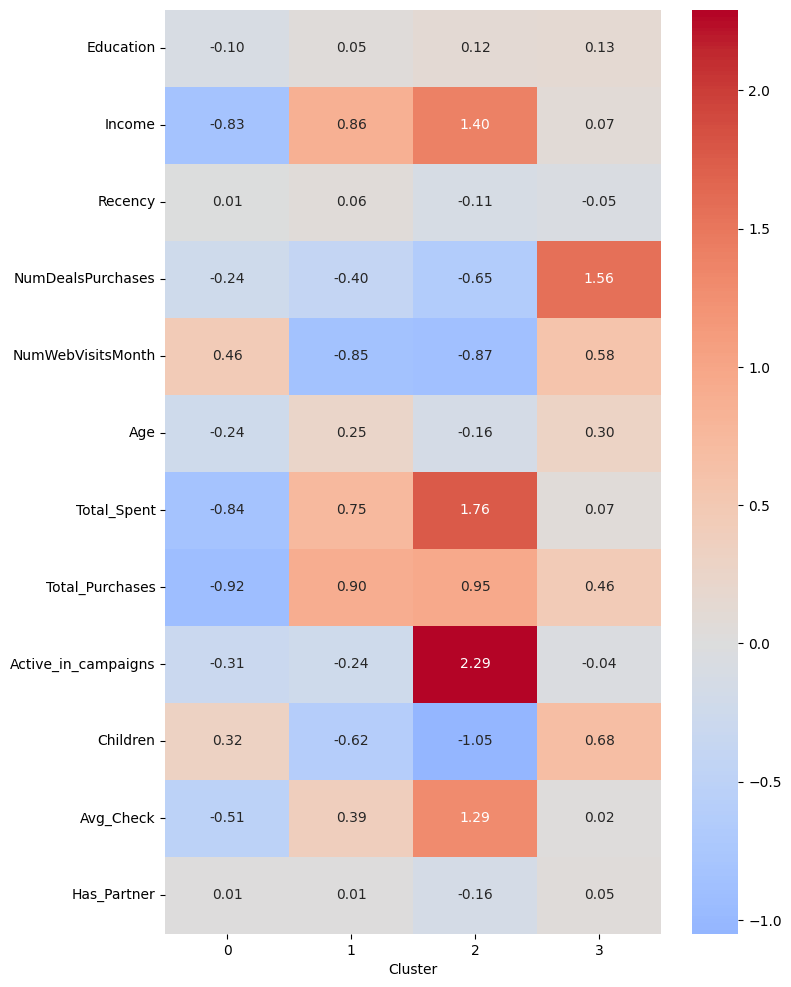

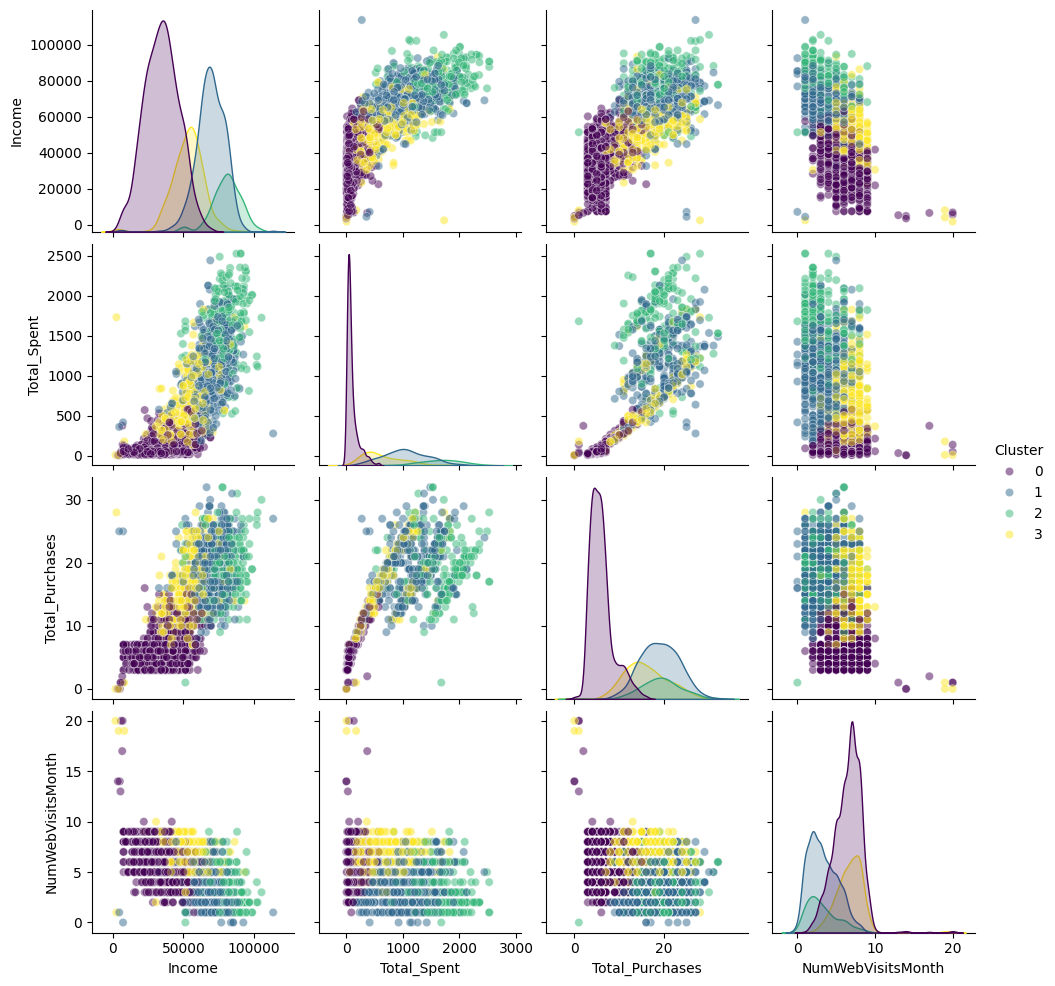

Cluster,0,1,2,3
Income,34416.50,69681.5000,81246.00,53860.500000
Total_Spent,63.00,1033.0000,1685.00,561.500000
Total_Purchases,5.00,19.0000,19.00,15.000000
Avg_Check,12.25,49.3125,94.95,34.789474
Age,41.00,49.0000,42.00,48.000000
Children,1.00,0.0000,0.00,1.000000
NumWebVisitsMonth,7.00,3.0000,3.00,7.000000
NumDealsPurchases,2.00,1.0000,1.00,5.000000
Active_in_campaigns,0.00,0.0000,2.00,0.000000


In [80]:
# Фінальна кластеризація: 12 ознак, k=4
X, X_scaled = prepare(df, feature_names_last)

kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_final = kmeans_final.fit_predict(X_scaled)
df["Cluster"] = labels_final

print("silhouette:", round(metrics.silhouette_score(X_scaled, labels_final), 3))
print("розміри:   ", np.bincount(labels_final))

clustering_analysis(df, X_scaled, labels_final, feature_names_last,
                    plot_cols=["Income", "Total_Spent", "Total_Purchases", "NumWebVisitsMonth"])

df.groupby("Cluster")[["Income", "Total_Spent", "Total_Purchases", "Avg_Check",
                       "Age", "Children", "NumWebVisitsMonth",
                       "NumDealsPurchases", "Active_in_campaigns"]].median().T

In [81]:
#оцінка стабільності кластеризації
base = KMeans(4, random_state=0, n_init=10).fit_predict(X_scaled)
for seed in [1, 7, 42, 100]:
    other = KMeans(4, random_state=seed, n_init=10).fit_predict(X_scaled)
    print(seed, round(adjusted_rand_score(base, other), 3))

1 0.986
7 0.676
42 1.0
100 0.99


##Висновки
###Робота з ознаками
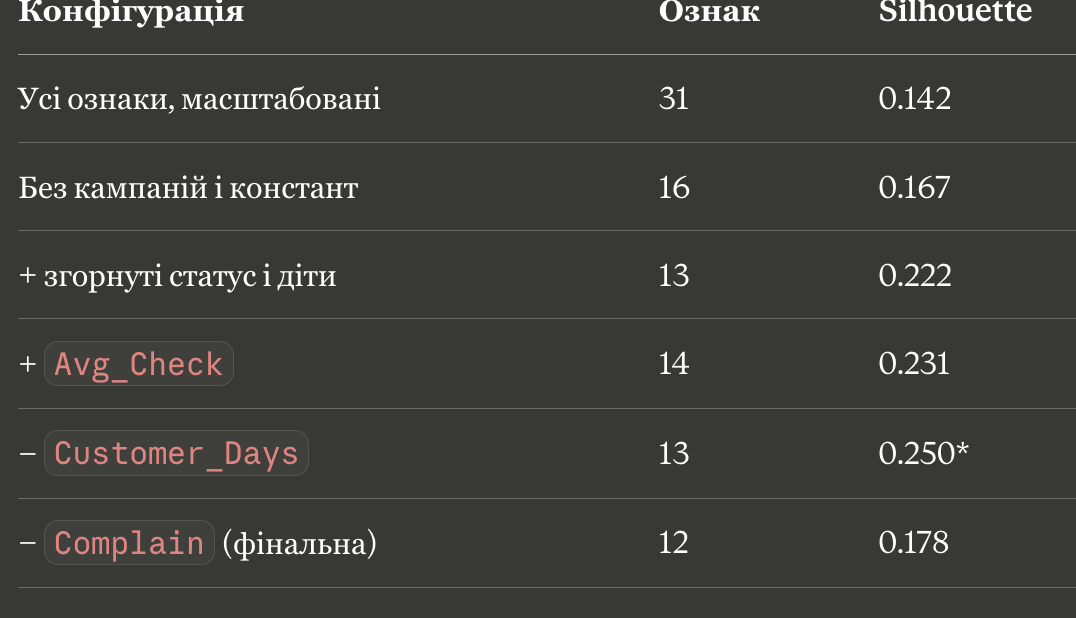

* найвища метрика, але один із трьох кластерів складався з 20 скаржників.

Перетворення: AcceptedCmp1–5 + Response → Active_in_campaigns; шість Mnt* → Total_Spent; три Num*Purchases → Total_Purchases; чотири one-hot статусу → Has_Partner; Kidhome + Teenhome → Children; додано Avg_Check; видалено константи й Customer_Days.

Avg_Check формально виводиться з двох інших ознак, але покращив метрику: ділення нелінійне, і евклідова відстань його самостійно не відтворює.
###Наскрізне спостереження: рідкісні бінарні ознаки
Один ефект проявився шість разів: четвертий кластер KMeans визначався лише Marital_Status_Single; IsolationForest позначив аномаліями клієнтів з рідкісними AcceptedCmp*; група з 20 у single linkage повністю визначалась Complain; DBSCAN при eps=2 побудував кластери як перетини бінарних ознак; автовідбір ознак для DBSCAN дав 4 бінарні з 5; конфігурація з найвищим silhouette містила кластер з 20 скаржників.

Причина: після стандартизації одиниця в майже завжди нульовій колонці дає відхилення 8–9σ. Для порівняння Has_Partner з балансом 64/36 дає 0.75σ і проблем не створює — справа не в бінарності, а в рідкісності.
###Порівняння методів
KMeans — єдиний метод зі збалансованими сегментами. Фінал: 12 ознак, k=4, silhouette 0.182, розміри [1012, 608, 400, 209].

Single linkage — вироджений результат [2228, 1] і [2224, 4, 1] через ефект ланцюжка. Silhouette 0.557 і 0.451 — найвищі в роботі, бо одиничні кластери мають нульову внутрішню відстань. Метрику необхідно читати разом із розмірами кластерів.

DBSCAN за всіх eps дає один кластер на 54–97% спостережень плюс дрібні групи. При eps=2 шумом визнано 77% вибірки, причому саме найактивніших клієнтів (витрати 760 проти 48–224). Метрика непорівнянна з KMeans, бо рахується лише за кластеризованими точками. Придатний як детектор аномалій, не для сегментації.

###Вибір k
Лікоть згладжений: приріст падає з ~11800 (k=1→2) до ~3700, ~2600 і ~900 при k=4→5. Silhouette: 0.246 (k=2), 0.178 (k=3), 0.182 (k=4). Формально найкращий k=2, але це тривіальний поділ на активних і неактивних. Обрано k=4 — різниця з k=3 незначна (0.004), проте чотири профілі описуються різними словами, тоді як k=3 зливає мисливців за знижками із заможними покупцями.

Стабільність (adjusted Rand index між запусками з різними random_state): 0.99, 1.00, 0.99, 0.68. Три з чотирьох запусків дають ідентичне розбиття; розбіжність в одному вказує на альтернативний локальний оптимум.
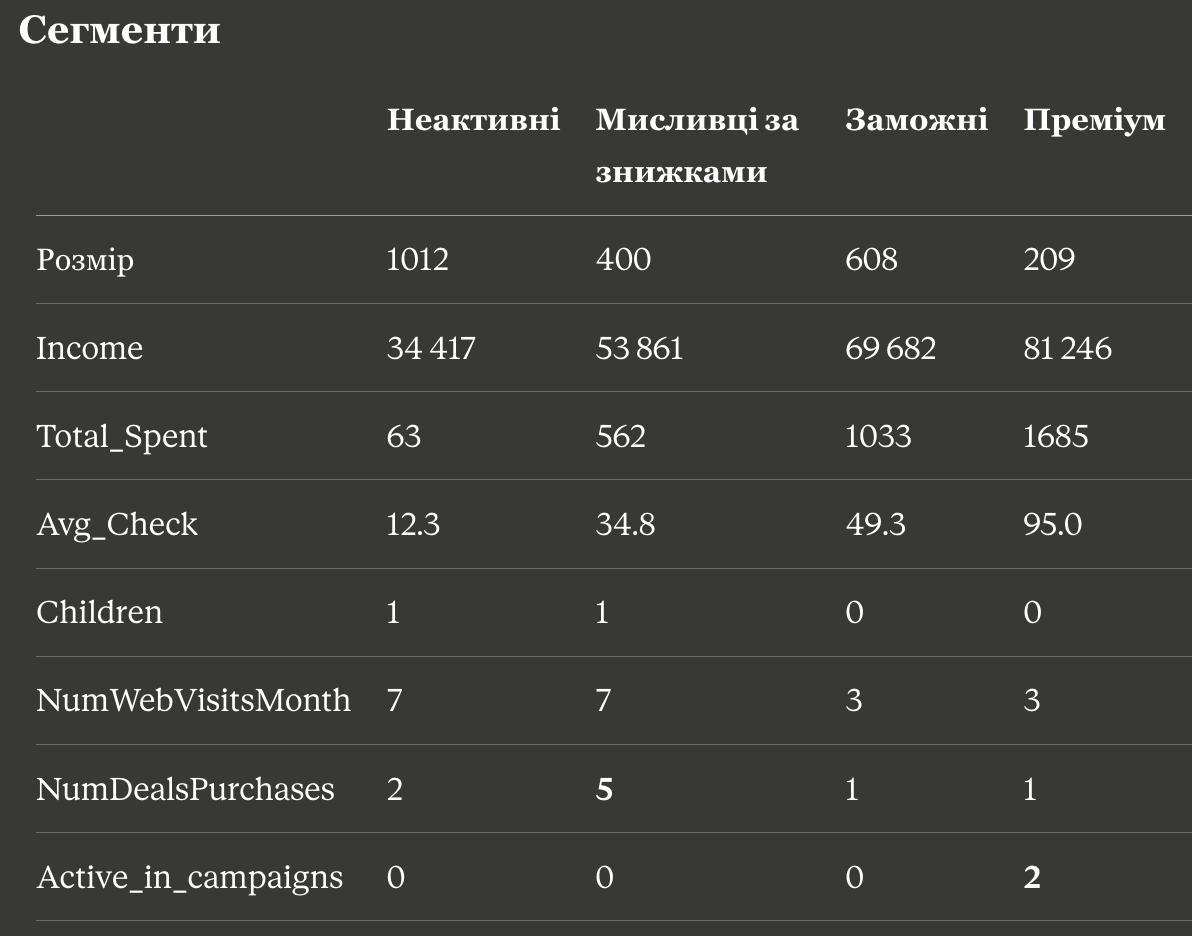
Частота відвідувань сайту змінюється обернено до витрат: 7 візитів у двох нижніх сегментах проти 3 у верхніх — перші довго вибирають, другі приходять і купують. Рекламні кампанії досягали виключно преміального сегмента, решта 90% бази на них не відгукувалась. Recency у сегментації не бере участі взагалі (48–50 днів у всіх кластерах).
###Обмеження
Клієнти утворюють неперервний градієнт за рівнем споживання без природних розривів. Це підтверджують чотири незалежні спостереження: згладжений лікоть, невисокий silhouette за будь-якої конфігурації, ефект ланцюжка в ієрархічній кластеризації та нездатність DBSCAN знайти області різної щільності.

Отримані сегменти — зручний поділ континууму, а не виявлення об'єктивно існуючих груп: межі умовні й залежать від набору ознак. Цього може бути достатньо для маркетингу цього достатньо, але підстав стверджувати, що в базі існують саме чотири природні типи клієнтів, немає.